# Описание датасета

## Ссылка на датасет

https://www.kaggle.com/datasets/marklvl/bike-sharing-dataset

## Общая информация
Датасет содержит данные о прокате велосипедов в Washington D.C. через систему проката велосипедов

## Структура данных

### Основные поля

| Поле | Тип | Описание |
|------|-----|----------|
| `instant` | integer | Уникальный индекс записи |
| `dteday` | date | Дата (гггг-мм-дд) |
| `season` | integer | Сезон: 1-весна, 2-лето, 3-осень, 4-зима |
| `yr` | integer | Год: 0-2011, 1-2012 |
| `mnth` | integer | Месяц: от 1 до 12 |
| `hr` | integer | Час: от 0 до 23 (только в hour.csv) |
| `holiday` | integer | Праздничный день: 1-праздник, 0-не праздник |
| `weekday` | integer | День недели: от 0 до 6 |
| `workingday` | integer | Рабочий день: 1 если не выходной и не праздник, иначе 0 |
| `weathersit` | integer | Погодные условия |

### Детализация погодных условий (`weathersit`)

| Код | Описание |
|-----|----------|
| 1 | Ясно, мало облаков, переменная облачность |
| 2 | Туман + облачно, туман + разорванные облака, туман + мало облаков |
| 3 | Небольшой снег, небольшой дождь + гроза + рассеянные облака, небольшой дождь + рассеянные облака |
| 4 | Сильный дождь + ледяная крупа + гроза + туман, снег + туман |

### Метеорологические данные (нормализованные)

| Поле | Описание | Диапазон |
|------|----------|----------|
| `temp` | Нормализованная температура в °C: (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 | [0, 1] |
| `atemp` | Нормализованная ощущаемая температура в °C: (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 | [0, 1] |
| `hum` | Нормализованная влажность: значения разделены на 100 (максимум) | [0, 1] |
| `windspeed` | Нормализованная скорость ветра: значения разделены на 67 (максимум) | [0, 1] |

### Целевые переменные

| Поле | Описание |
|------|----------|
| `casual` | Количество незарегистрированных (временных) пользователей |
| `registered` | Количество зарегистрированных пользователей |
| `cnt` | Общее количество арендованных велосипедов (casual + registered) |

## Особенности данных

- **Временной период**: 2011-2012 годы
- **Разные датасеты**: Почасовые и дневные данные
- **Нормализация**: Метеорологические данные нормализованы к диапазону [0, 1]
- **Сезонность**: Учет сезонных изменений и погодных условий
- **Природа признаков**:
    - dteday, season, yr, mnth, hr, holiday, weekday, workingday - признаки, образованные из даты и времени.
    - weathersit, temp, atemp, hum, windspeed - признаки, образованные из данных о погоде.
    - casual, registered, cnt - признаки, образованные из таргета cnt, и сам таргет.


## Использование для прогнозирования

Датасет подходит для задач:
- Прогнозирования спроса на прокат велосипедов
- Анализа влияния погодных условий на спрос
- Изучения сезонных паттернов использования
- Сравнения поведения зарегистрированных и временных пользователей

## Наша задача
- Прогнозирование cnt - спроса на прокат велосипедов в конкретный час на основе временных и погодных признаков.

# Этап 0. Выгрузка данных

In [70]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("marklvl/bike-sharing-dataset")

# print("Path to dataset files:", path)

In [71]:
# !pip install pyod category_encoders shap lime catboost optuna

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

from catboost import CatBoostRegressor

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge



from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import optuna


In [73]:
# df = pd.read_csv(os.path.join(path, "hour.csv"))
# df.head()

In [74]:
from pathlib import Path

Path("./data/raw")


PosixPath('data/raw')

In [75]:
with open(f"./data/raw/hour.csv", "r") as data_file:
    if data_file is not None:
        df = pd.read_csv(data_file)


In [76]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [77]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [78]:
print(df.shape)
display(df.info())
display(df.isna().sum())
display(df.duplicated().sum())

(17379, 17)
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


None

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

np.int64(0)

In [79]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

# Этап 1. EDA

In [80]:
def _get_series(df, column, dropna):
    if column not in df.columns:
        raise ValueError(f"Колонка '{column}' отсутствует в DataFrame.")

    series = df[column].dropna() if dropna else df[column]
    if series.empty:
        raise ValueError(f"После удаления пропусков колонка '{column}' пуста.")

    return series

def _get_df_data(df, x, y, dropna):
    if x not in df.columns or y not in df.columns:
        raise ValueError("Обе колонки должны быть в DataFrame.")

    data = df[[x, y]].dropna() if dropna else df[[x, y]]
    if data.empty:
        raise ValueError(f"После удаления пропусков данные по колонкам '{x}' и '{y}' пусты.")

    return data

def _add_title_and_labels(ax, title, xlabel, ylabel, defaultx, defaulty):
    if title:
        ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel else defaultx)
    ax.set_ylabel(ylabel if ylabel else defaulty)

def plot_box(df, column,
             figsize=(8, 6),
             title=None,
             xlabel=None,
             ylabel=None,
             dropna=True):

    series = _get_series(df, column, dropna)

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        y=series,
        ax=ax,
        showfliers=True,
        fliersize=5,
    )

    _add_title_and_labels(ax, title, xlabel, ylabel, "", column)

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


def plot_hist(df, column,
              figsize=(8, 6),
              title=None,
              xlabel=None,
              ylabel=None,
              dropna=True,
              bins=30,
              meanline=True,
              medline=True,
              midline=False,
              mx=None,
              mn=None):

    series = _get_series(df, column, dropna)

    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(series, bins=bins)

    if meanline:
        mean_val = series.mean()
        ax.axvline(mean_val, color='red', linewidth=2, label=f"Mean = {mean_val:.2f}")

    if medline:
        med_val = series.median()
        ax.axvline(med_val, color='black', linewidth=2, label=f"Median = {med_val:.2f}")

    if midline:
        if mx is None:
            mx = series.max()
        if mn is None:
            mn = series.min()
        mid_val = (mx + mn) / 2
        ax.axvline(mid_val, color='red', linewidth=1.5, linestyle='--',
                   alpha=0.5, label=f"Mid = {mid_val:.2f}")

    _add_title_and_labels(ax, title, xlabel, ylabel, column, "Count")
    if meanline or medline or midline:
        ax.legend()

    plt.tight_layout()
    plt.show()



def plot_scatter(df, x, y,
                 figsize=(8, 6),
                 title=None,
                 xlabel=None,
                 ylabel=None,
                 dropna=True):
    data = _get_df_data(df, x, y, dropna)

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(data[x], data[y], s=10)

    _add_title_and_labels(ax, title, xlabel, ylabel, x, y)

    plt.tight_layout()
    plt.show()


def plot_line(df, x, y,
              figsize=(10, 5),
              title=None,
              xlabel=None,
              ylabel=None,
              dropna=True,
              xticks=None,
              xtick_rotation=0,
              xgrid=False,
              ax = None,
              should_show=True,
              label = None):
    data = _get_df_data(df, x, y, dropna)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.plot(data[x], data[y], label=label)

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=xtick_rotation)

    if xgrid:
        ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)

    _add_title_and_labels(ax, title, xlabel, ylabel, x, y)

    if should_show:
        if label is not None:
            ax.legend()
        plt.tight_layout()
        plt.show()
    return ax

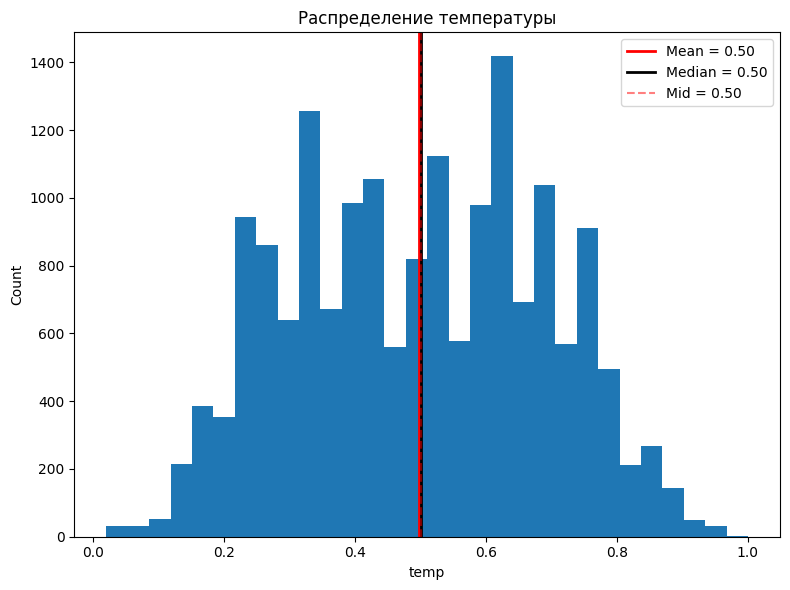

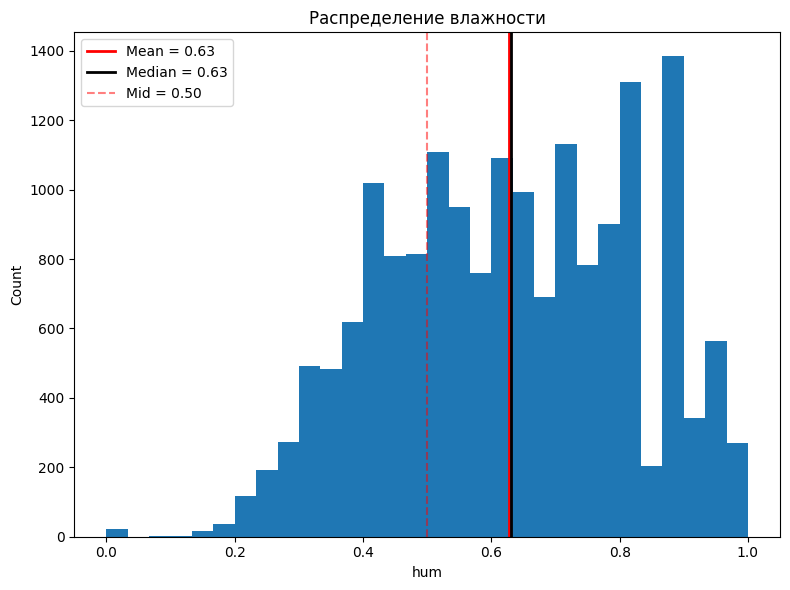

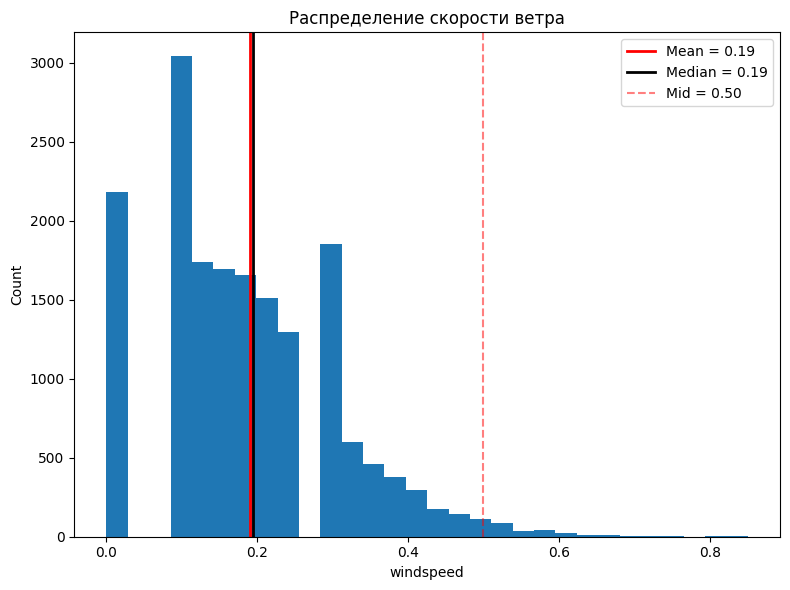

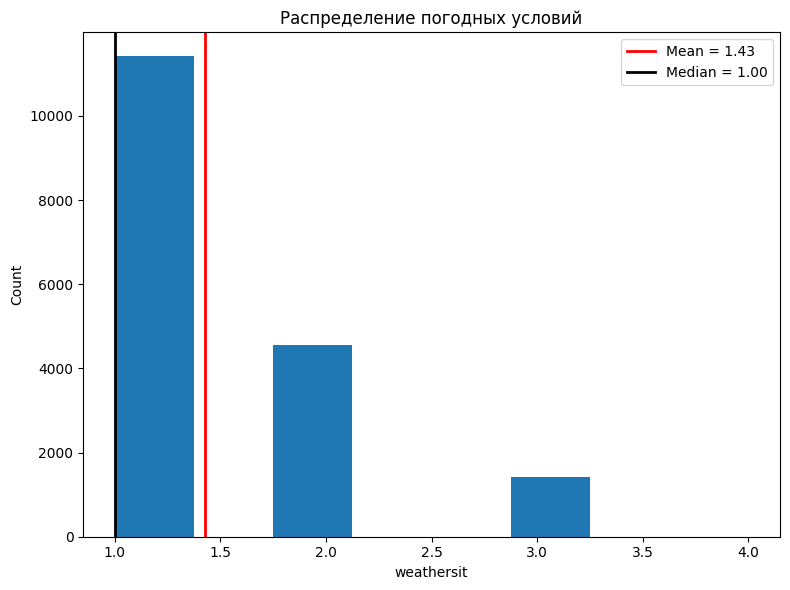

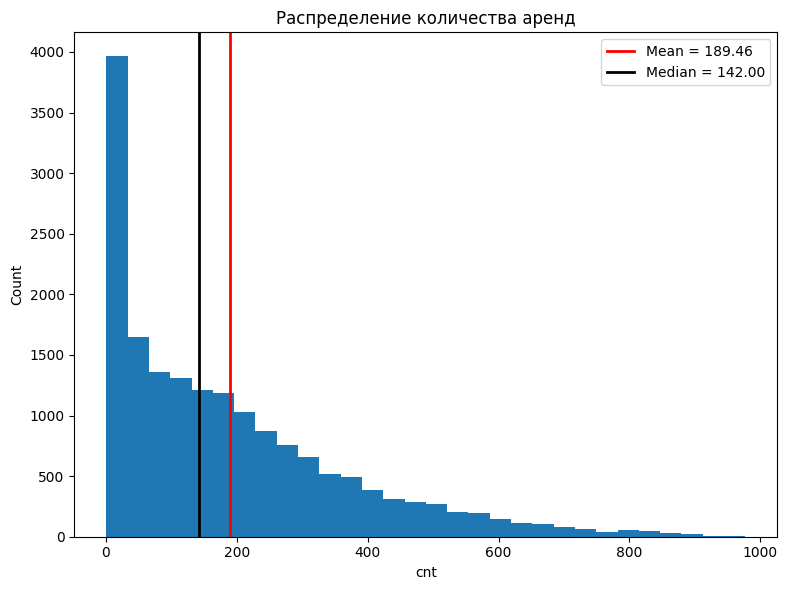

In [81]:
plot_hist(df, "temp", title="Распределение температуры", midline=True, mx=1.0, mn=0.0)
plot_hist(df, "hum", title="Распределение влажности", midline=True, mx=1.0, mn=0.0)
plot_hist(df, "windspeed", title="Распределение скорости ветра", midline=True, mx=1.0, mn=0.0)
plot_hist(df, "weathersit", title="Распределение погодных условий", bins=8)
plot_hist(df, "cnt", title="Распределение количества аренд")

In [82]:
(df["weathersit"]==4).sum()

np.int64(3)

- Распределение температуры похоже на нормальное. Относительно симметричное и одновершинное. Наиболее частая температура 15.5°C (В описании датасета на kaggle есть max/min значения до нормализации).
- Большая часть значений лежит между 0.48 - 0.78: преобладает средняя или высокая влажность. Медианная влажность около 63%.
- Распределение windspeed скошено вправо: большинство наблюдений имеет низкую или умеренную скорость ветра, а высокие значения встречаются редко. Медианная скорость ветра - 12.7 mph ≈ 5.7 м/с
- Чаще всего в датасете хорошая погода (weatherit = 1). медиана равна 1. Распределение скошено вправо. Мало данных с плохой погодой.
- всего три записи с weathersit = 4 из 18 тысяч. нужно будет позже обработать эти случаи отдельно (объединить с 3-им)
- Очевидно, преобладают часы с небольшим количеством аренд, медиана составляет 142 аренды в час, а среднее - 189. При этом встречаются и пиковые часы с очень высоким спросом, максимум достигает 977 аренд. Распределение сильно скошено вправо

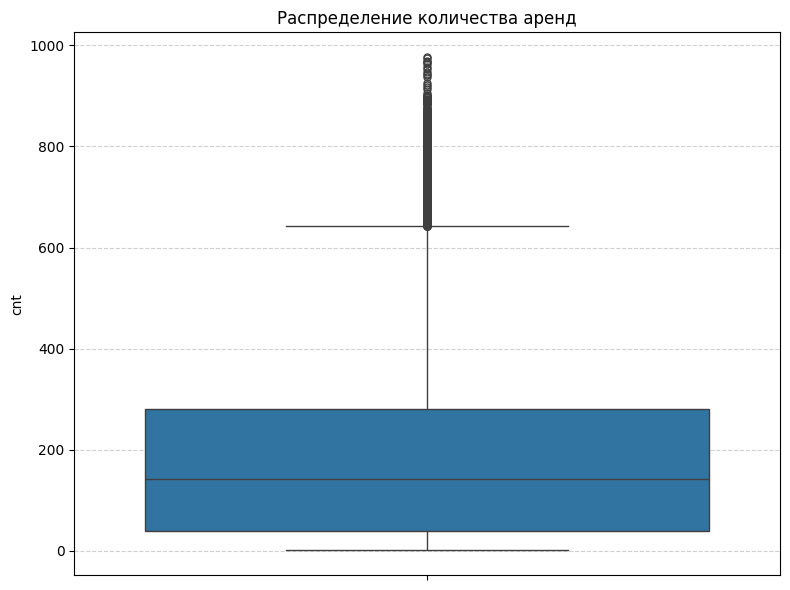

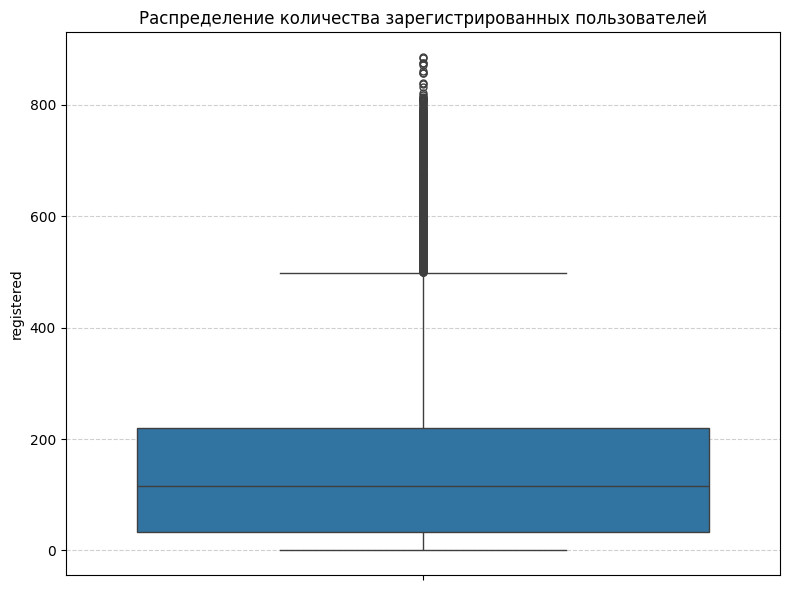

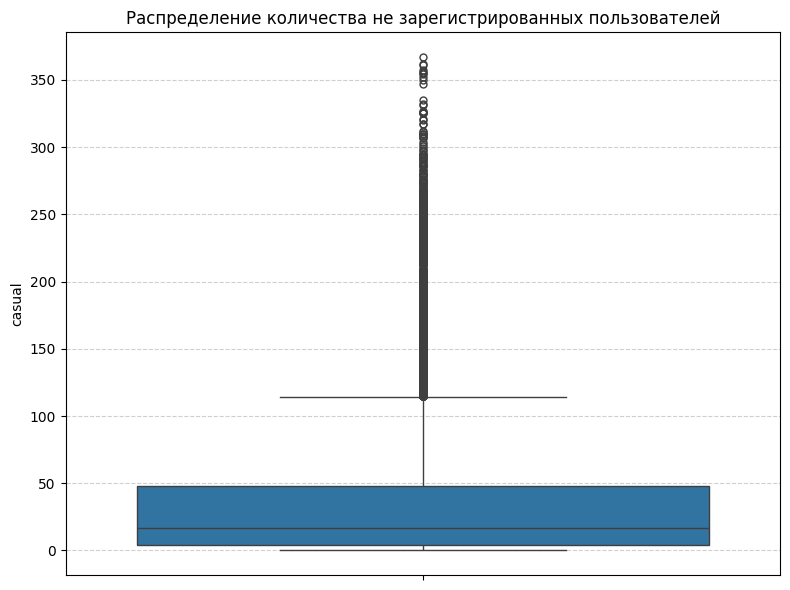

In [83]:
plot_box(df, "cnt", title="Распределение количества аренд")
plot_box(df, "registered", title="Распределение количества зарегистрированных пользователей")
plot_box(df, "casual", title="Распределение количества не зарегистрированных пользователей")

- Количество аренд держится в районе 50-280 в час
- Количество зарегистрированных пользователей преобладает над числом незарегистрированных.

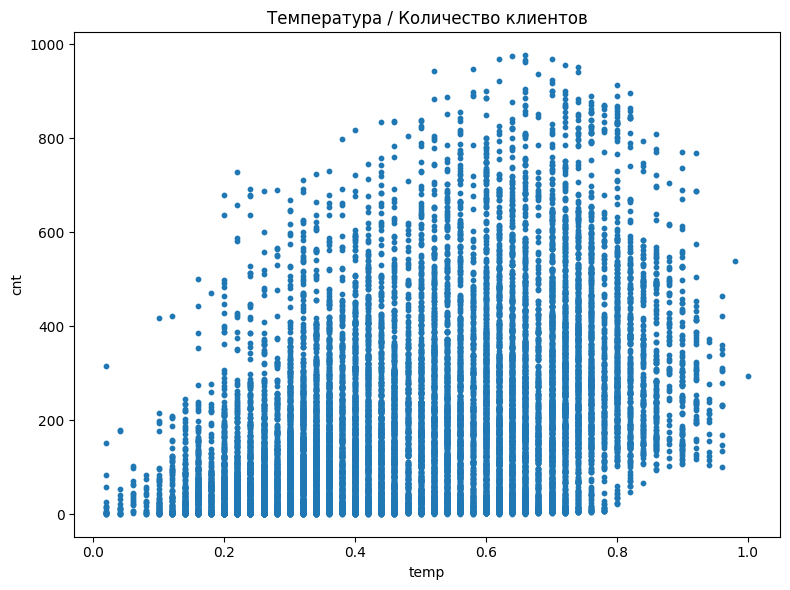

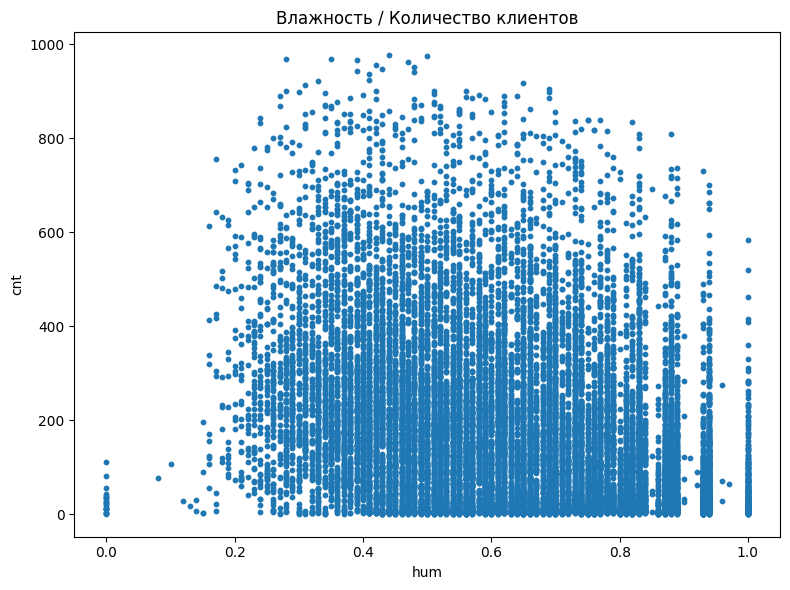

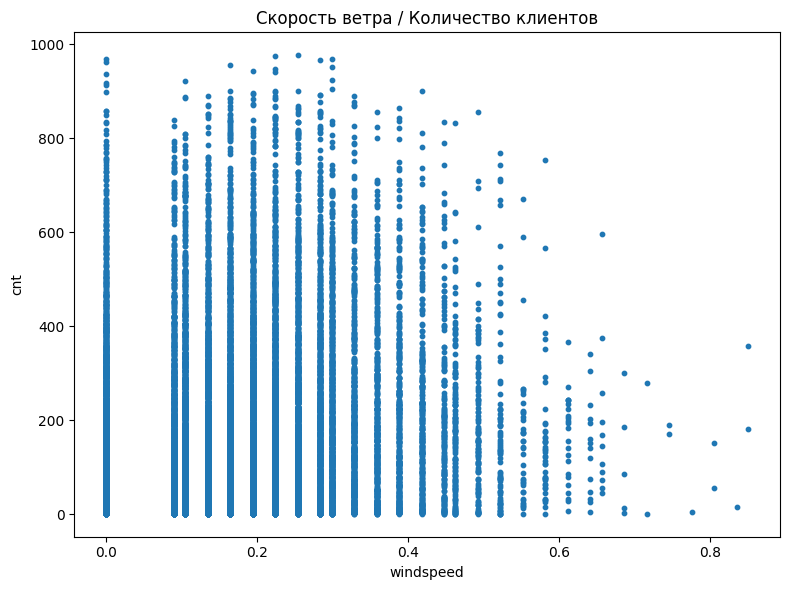

In [84]:
plot_scatter(df, "temp", "cnt", title="Температура / Количество клиентов")
plot_scatter(df, "hum", "cnt", title="Влажность / Количество клиентов")
plot_scatter(df, "windspeed", "cnt", title="Скорость ветра / Количество клиентов")

- Между кол-вом аренд и температурой есть положительная зависимость. при низкой температуре клиенты редко арендуют велосипеды. чем выше температура, тем, как правило, больше аренд велосипедов.
- Наибольшее число клиентов достигается при значении температуры около 0.6
- При высокой влажности высокие значения cnt встречаются реже.
- Между скоростью ветра и арендой велосипеда есть отрицательная зависимость. чем выше скорость ветра, тем меньше клиентов

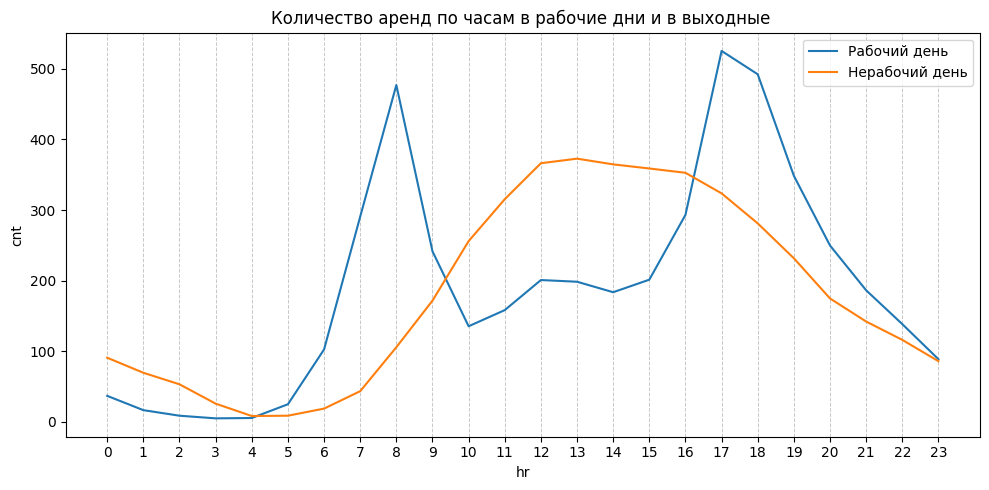

<Axes: title={'center': 'Количество аренд по часам в рабочие дни и в выходные '}, xlabel='hr', ylabel='cnt'>

In [85]:
work = df[df["workingday"] == 1].groupby("hr")["cnt"].mean().reset_index()
nowork = df[df["workingday"] == 0].groupby("hr")["cnt"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,5))

plot_line(work, "hr", "cnt", ax=ax, should_show=False, label="Рабочий день")
plot_line(nowork, "hr", "cnt", title="Количество аренд по часам в рабочие дни и в выходные ",
           xticks=range(0, 24), xgrid=True, ax=ax,label="Нерабочий день")


- В будние дни:
    - Отчётливо видны пики спроса отчётливо видны пики спроса в 8 и 17 часов - в это время многие добираются на работу или домой, поэтому спрос подскакивает
    - Есть подъём спроса с 12 до 15 часов. Вероятно, люди берут велосипеды для коротких поездок по городу - обеденный перерыв, личные дела, перемещения между районами.
    - Ночью почти нет клиентов
- В выходные 
    - Спрос имеет выраженный дневной пик - кол-во клиентов постепенно растёт утром, достигает максимума примерно с 12 до 16 часов, а затем снижается к вечеру. В отличие от рабочих дней, нет резких пиков в 8 и 17 часов, связанных с поездками на работу и домой. Вероятно, в выходные велосипеды чаще используют для личных дел.
    - Спрос более равномерный, без резких пиков спроса.
- Спрос на велосипеды в будние дни и в выходные различается

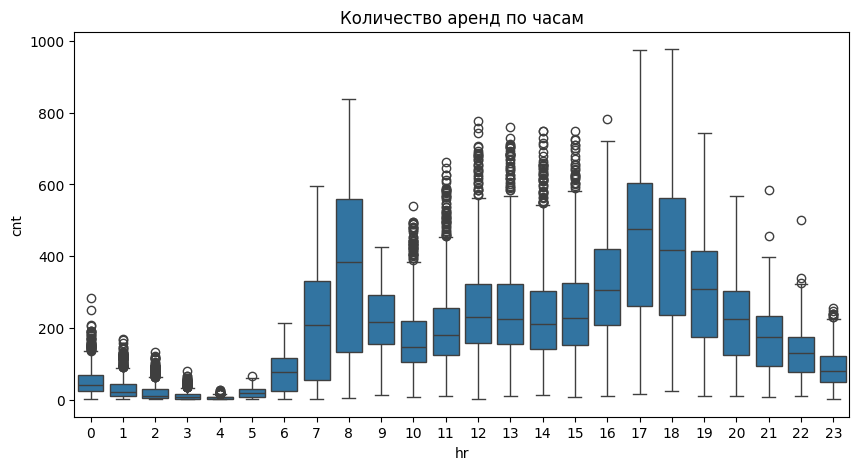

In [86]:
plt.figure(figsize=(10,5))
sns.boxplot(x='hr', y='cnt', data=df)
plt.title('Количество аренд по часам')
plt.show()

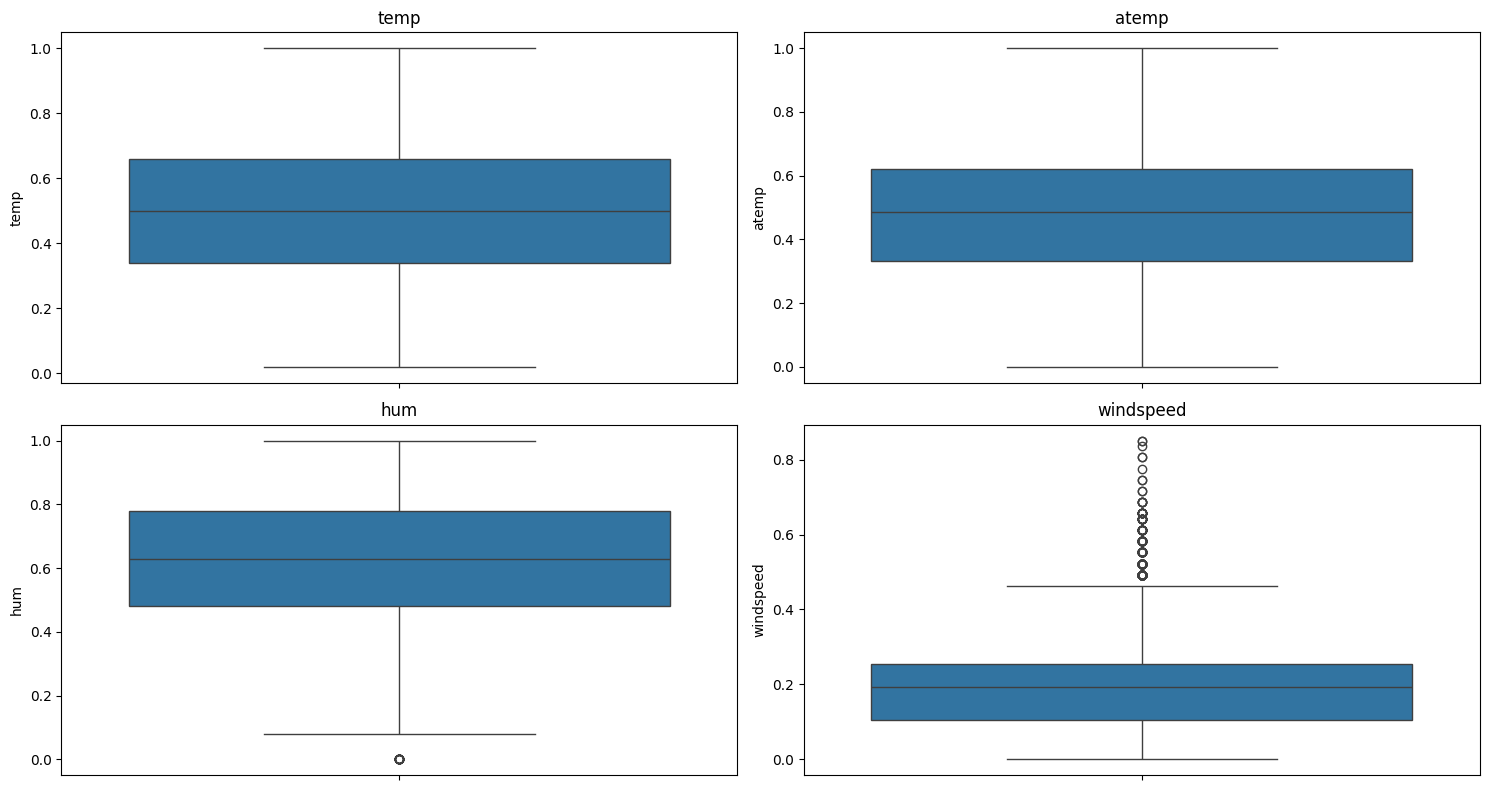

In [87]:
num_cols = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [88]:
max_wind = df["windspeed"].max()
display(df[df["windspeed"]==max_wind])

print('\n'*3)
max_hum = df["hum"].max()
display(df[df["hum"]==max_hum].head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
4315,4316,2011-07-03,3,0,7,17,0,0,0,3,0.8,0.7424,0.49,0.8507,181,177,358
4316,4317,2011-07-03,3,0,7,18,0,0,0,3,0.8,0.7424,0.49,0.8507,74,107,181


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
26,27,2011-01-02,1,0,1,2,0,0,0,2,0.42,0.4242,1.0,0.2836,1,8,9
721,722,2011-02-02,1,0,2,10,0,3,1,2,0.22,0.2727,1.0,0.0000,2,59,61
786,787,2011-02-05,1,0,2,5,0,6,0,3,0.20,0.2273,1.0,0.0896,0,9,9
787,788,2011-02-05,1,0,2,6,0,6,0,3,0.20,0.2576,1.0,0.0000,0,4,4
789,790,2011-02-05,1,0,2,8,0,6,0,3,0.20,0.2273,1.0,0.0896,0,10,10


Видно, что у hum  и windspeed есть выбросы боксплота, но это просто необычные погодные условия. удалять такие строки будет ошибкой.

также у temp/atemp нет boxplot fliers

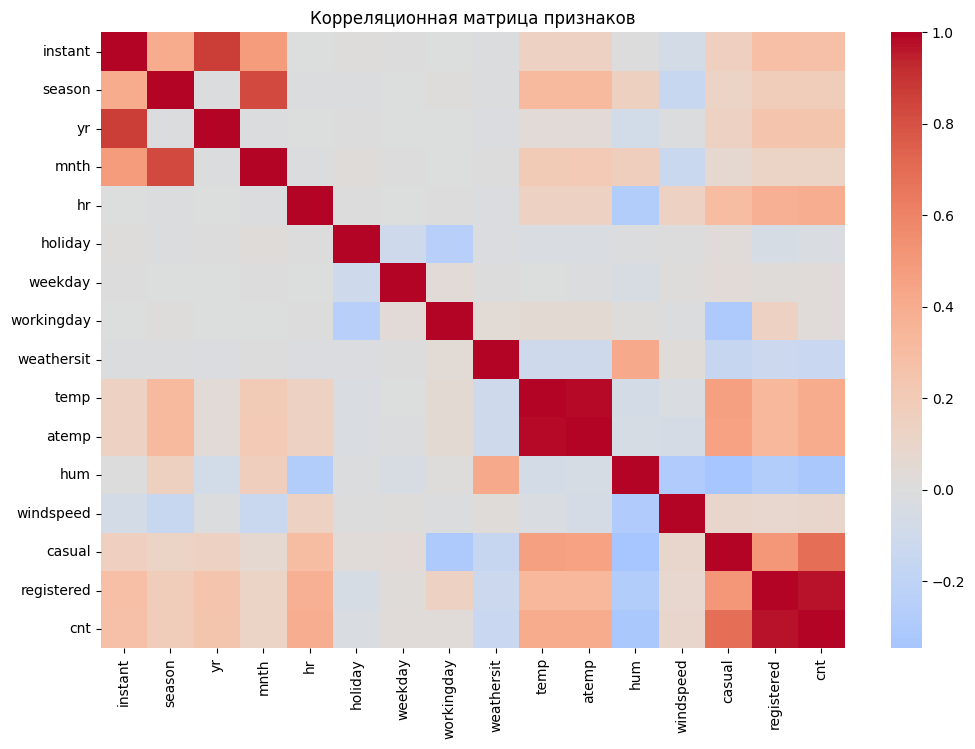

In [89]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=["dteday"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

- temp и atemp сильно коррелируют. Это очевидно и следует из природы данных - atemp отражает ощущаемую температуру.

- Также видно сильную корреляцию между cnt, registered и casual. Это тоже очевидно -  cnt является суммой зарегистрированных и незарегистрированных пользователей: cnt = registered + casual. Поэтому registered и casual нельзя использовать как признаки при предсказании cnt, иначе модель будет получать почти прямую информацию о целевой переменной (утечка данных).

- Между cnt и температурными признаками (temp, atemp) есть положительная корреляция. Это подтверждает наблюдения из scatter plot - при более комфортной температуре спрос на велосипеды обычно выше.

- cnt также коррелирует с признаками, связанными с датой и временем. Это значит, что есть временные паттерны - спрос зависит от часа дня, сезона, месяца.

- Интересное различие видно для признака workingday - он положительно связан с registered, но отрицательно с casual. Можно сказать, что в рабочие дни велосипеды чаще используют зарегистрированные пользователи, вероятно, для регулярных поездок на работу или учёбу. Незарегистрированные пользователи, наоборот, активнее в нерабочие дни, что похоже на нерегулярные поездки, прогулки или досуг.

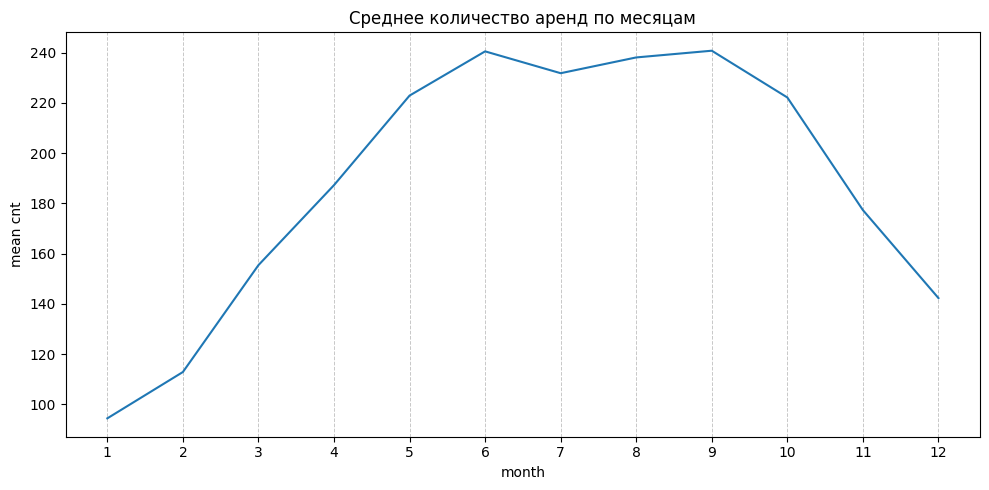

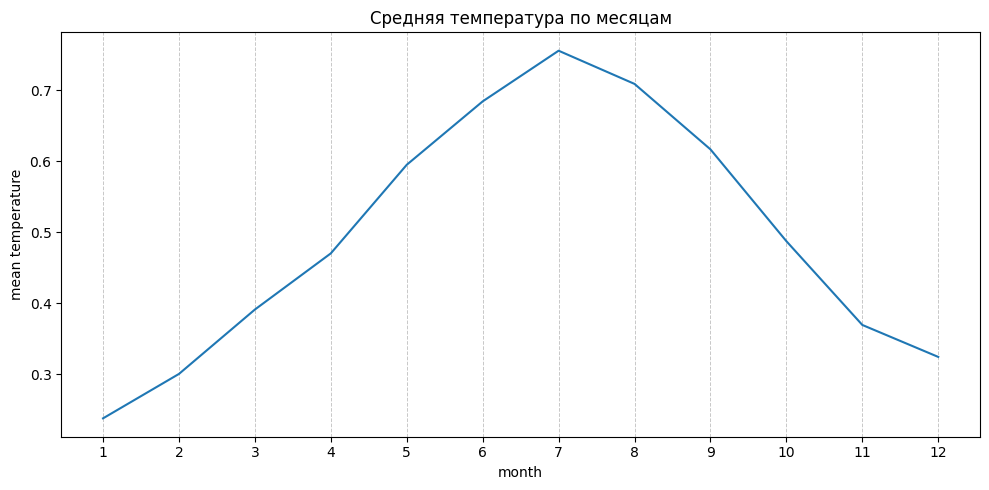

In [90]:
month_mean_cnt = df.groupby("mnth")["cnt"].mean().reset_index()
plot_line(month_mean_cnt, "mnth", "cnt",
          title="Среднее количество аренд по месяцам",
          xlabel="month", ylabel="mean cnt", xticks=range(1,13),
          xgrid=True)

month_mean_temp = df.groupby("mnth")["temp"].mean().reset_index()
plot_line(month_mean_temp, "mnth", "temp",
          title="Средняя температура по месяцам",
          xlabel="month", ylabel="mean temperature", xticks=range(1,13),
          xgrid=True)
print()


- зачем я построил второй график - данные собраны в Washington D.C. Погода по сезонам там может отличаться от привычной для Москвы - к примеру, там может быть всегда тепло.
- Видно, что среднее кол-во аренд сильно зависит от месяца. Минимальный спрос наблюдается зимой, особенно в январе и феврале. Затем спрос постепенно растёт весной, достигает максимума летом и в начале осени, после чего снова снижается к зиме.

- Динамика спроса в целом похожа на динамику температуры: когда средняя температура растёт, увеличивается и среднее число аренд. Это еще раз подтверждает вывод из scatter plot о положительной связи между температурой и спросом на велосипеды.

- При этом максимум спроса приходится не строго на самый жаркий месяц. Средняя температура достигает пика в июле, а количество аренд остаётся высоким в июне–сентябре. Можно сказать, что на спрос влияет не сама температура, а комфортность погоды.

- В целом графики показывают выраженную сезонность: велосипеды значительно активнее используют в тёплые месяцы, а зимой спрос заметно падает. Поэтому не стоит позже использовать sliding window, лучше expanding window, чтобы не забывать исторические данные и чтобы обучаться в том числе на сезонности спроса.

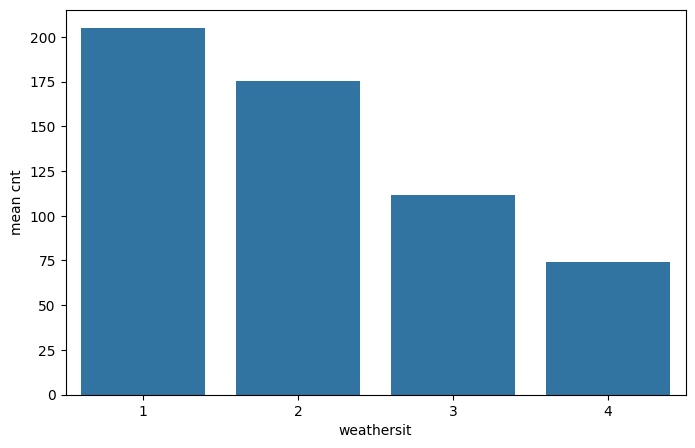

In [91]:
weathersit_mean = df.groupby("weathersit")["cnt"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=weathersit_mean, x="weathersit", y="cnt")
plt.xlabel("weathersit")
plt.ylabel("mean cnt")
plt.show()

чем больше weathersit - тем хуже погода.

- очевидно, что чем хуже погода (т.е. чем больше weathersit) - тем меньше среднее кол-во аренд велосипедов.

# Этап 2. Построим baseline

Для baseline модели построим сезонный статистический прогноз - среднее значение cnt (спроса) по комбинации признаков. Дополнительно для сравнения обучим Linear regression с Ridge регуляризацией.

### Разделим данные на train/val/test, удалим служебные признаки/таргет

In [92]:
df['timestamp'] = (
    pd.to_datetime(df["dteday"]) +
    pd.to_timedelta(df["hr"], unit="h")
)
#исторические данные - сортируем, чтобы случайно не было утечки данных из будущего.
df = df.sort_values("timestamp").reset_index(drop=True)

test_size = int(len(df) * 0.20)
train_val_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

val_size = int(len(train_val_df) * 0.20)
train_df = train_val_df.iloc[:-val_size].copy()
val_df = train_val_df.iloc[-val_size:].copy()



print(f"train: {train_df['timestamp'].min()} - {train_df['timestamp'].max()} {train_df.shape}")
print(f"val: {val_df['timestamp'].min()} - {val_df['timestamp'].max()} {val_df.shape}")
print(f"test: {test_df['timestamp'].min()} - {test_df['timestamp'].max()} {test_df.shape}")



train: 2011-01-01 00:00:00 - 2012-04-13 16:00:00 (11124, 18)
val: 2012-04-13 17:00:00 - 2012-08-07 12:00:00 (2780, 18)
test: 2012-08-07 13:00:00 - 2012-12-31 23:00:00 (3475, 18)


In [93]:
categorical_features = [
    "yr",
    "season",
    "mnth",
    "hr",
    "weekday",
    "holiday",
    "workingday",
    "weathersit",
]

numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

feature_cols = categorical_features + numeric_features

X_train = train_df[feature_cols]
y_train = train_df["cnt"]

X_val = val_df[feature_cols]
y_val = val_df["cnt"]

X_test = test_df[feature_cols]
y_test = test_df["cnt"]

### Сезонный статистический baseline

Построим статистический baseline, основанный на календарных паттернах спроса. Сгруппируем данные по признакам (выберем их позже) и посчитаем среднее значение cnt внутри каждой группы. Прогнозом будет среднее cnt для такой же комбинации признаков.




Найдем признаки-кандидаты, протестируем их комбинации на val выборке, и выберем лучшие.

- Сразу исключим из кандидатов все вещественные признаки, т.к. они сделают наши группы слишком разреженными. (temp, atemp, hum, windspeed)

- Исключим признак season, тк он однозначно восстанавливается из mnth. Группировка (season, mnth, other...) не отличается от (mnth, others...)

- Исключим признак yr, тк у нас всего два года в данных, и мы используем хронологический split. в train выборке (на которой мы считаем наше среднее) есть данные за весь первый год + данные за второй год до апреля. а оцениваем мы на данных второго года после апреля. если добавить yr, то для test_df и val_df данные будут только за январь-апрель второго года - весь первый год окажется бесполезным, т.к. ни одна группа из val/test не содержит yr=0.

- Исключим признак holiday, т.к. праздник - это редкое событие. Добавление этого признака в условие для группировки вносит шум в нашу модель.

- Также исключим признак weathersit - этот признак распределен неравномерно, его  добавление будет сильно дробить данные.

In [94]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def add_result(result_array, model_name, y_true, preds):
    val_metrics = regression_metrics(y_true, preds)

    result_array.append({
        "model": model_name,
        **val_metrics
    })

def display_leaderboard(results):
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("RMSE").reset_index(drop=True)
    display(results_df)
results = []

In [95]:
def predict_group_mean(train_data, val_data, group_cols):
    group_mean = train_data.groupby(group_cols, as_index=False)["cnt"].mean().rename(columns={"cnt":"pred"})
    global_mean = train_data["cnt"].mean()

    val_with_pred = val_data[group_cols].merge(
        group_mean,
        on=group_cols,
        how="left",
    )

    return val_with_pred["pred"].fillna(global_mean).to_numpy()

In [96]:
def time_series_cv_splits(data, n_splits=5):
    splitter = TimeSeriesSplit(n_splits)
    splits = []

    for fold, (train_idx, val_idx) in enumerate(splitter.split(data), start=1):
        fold_train = data.iloc[train_idx].copy()
        fold_val = data.iloc[val_idx].copy()
        splits.append((fold, fold_train, fold_val))
    return splits


def summarize_cv_metrics(fold_metrics):
    metrics_df = pd.DataFrame(fold_metrics)

    summary = {}

    for metric in ["MAE", "RMSE", "R2"]:
        summary[f"mean_{metric}"] = metrics_df[metric].mean()
        summary[f"std_{metric}"] = metrics_df[metric].std()

    return summary


In [97]:
def evaluate_group_mean_cv(data, group_cols, n_splits=5):
    fold_metrics = []

    for fold, fold_train, fold_val in time_series_cv_splits(data, n_splits):
        fold_pred = predict_group_mean(
            train_data=fold_train,
            val_data=fold_val,
            group_cols=group_cols,
        )

        metrics = {
            "fold": fold,
            **regression_metrics(fold_val["cnt"], fold_pred)
        }

        fold_metrics.append(metrics)

    return {
        "group_cols": group_cols,
        **summarize_cv_metrics(fold_metrics),
    }


In [98]:
from itertools import combinations

seasonal_candidates = [
    "mnth",
    "hr",
    "weekday",
    "workingday",
]
all_combinations = []
for r in range(1, len(seasonal_candidates) + 1):
    all_combinations.extend(combinations(seasonal_candidates, r))

In [99]:
seasonal_results = []

for group_cols in all_combinations:
    group_cols = list(group_cols)

    seasonal_results.append(
        evaluate_group_mean_cv(
            data=pd.concat([train_df, val_df], axis=0).reset_index(drop=True),
            group_cols=group_cols,
            n_splits=5,
        )


    )

seasonal_results_df = pd.DataFrame(seasonal_results)
seasonal_results_df = seasonal_results_df.sort_values("mean_RMSE").reset_index(drop=True)
display(seasonal_results_df)


,group_cols,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,"[hr, weekday, workingday]",83.546455,34.564103,116.624018,41.528229,0.478662,0.274686
1,"[hr, workingday]",83.856768,34.123592,117.355914,41.373447,0.472948,0.271226
2,"[hr, weekday]",84.162616,34.336250,117.873951,40.951826,0.468414,0.268245
3,[hr],93.906045,30.770448,133.649198,40.682881,0.325024,0.250257
4,"[mnth, hr, workingday]",104.801498,16.949672,143.291489,25.468648,0.139013,0.382900
5,"[mnth, hr, weekday]",104.955200,16.497797,143.600567,25.394191,0.136298,0.380302
6,"[mnth, hr, weekday, workingday]",105.103274,16.593751,143.736049,25.701097,0.135464,0.379877
7,"[mnth, hr]",110.321763,15.166465,152.464339,24.076375,0.063454,0.327526
8,"[weekday, workingday]",137.935673,34.270379,180.437010,47.674655,-0.211775,0.203079
9,[weekday],137.968612,34.341752,180.473516,47.764550,-0.211964,0.201871


In [100]:
seasonal_results = []

for group_cols in all_combinations:
    group_cols = list(group_cols)
    val_preds =predict_group_mean(
            train_df,
            val_df,
            group_cols,
    )

    seasonal_results.append({
        "cols": group_cols,
        **regression_metrics(y_val, val_preds)
    })


seasonal_results_df = pd.DataFrame(seasonal_results)
seasonal_results_df = seasonal_results_df.sort_values("RMSE").reset_index(drop=True)
display(seasonal_results_df)

,cols,MAE,RMSE,R2
0,"[mnth, hr, workingday]",93.410464,128.505129,0.649352
1,"[mnth, hr, weekday]",93.924102,129.188771,0.645611
2,"[mnth, hr, weekday, workingday]",95.297240,130.556256,0.638069
3,"[mnth, hr]",106.792974,154.268456,0.494658
4,"[hr, weekday, workingday]",124.239764,165.485896,0.418496
5,"[hr, weekday]",124.637510,166.423682,0.411887
6,"[hr, workingday]",124.335321,166.459133,0.411636
7,[hr],133.164689,185.498935,0.269343
8,[mnth],179.504586,231.296114,-0.135972
9,"[mnth, workingday]",179.619728,231.441028,-0.137396


In [101]:
seasonal_val_pred = predict_group_mean(
    train_data=train_df,
    val_data=val_df,
    group_cols=["mnth", "hr", "workingday"],
)

add_result(results, "seasonal baseline", y_val, seasonal_val_pred)

### Linear Regression

In [102]:
linear_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", "passthrough", numeric_features),
    ])),
    ("model", LinearRegression()),
])
linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_val_pred = linear_model.predict(X_val)
display(pd.DataFrame([
    regression_metrics(y_train, linear_train_pred),
    regression_metrics(y_val, linear_val_pred)
]))



add_result(results, "linear regression base features", y_val, linear_val_pred)


,MAE,RMSE,R2
0,59.684479,80.547420,0.681161
1,108.616223,136.483401,0.604460


Качество модели на train и на val различается, так что попробуем ввести регуляризацию.

### Linear Regression + Ridge

In [103]:
alpha_metrics = []
ridge_alphas = [0.01, 0.1, 1, 10, 100]

for alpha in ridge_alphas:
    ridge_model = Pipeline([
        ("preprocess", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
            ("num", "passthrough", numeric_features),
        ])),
        ("model", Ridge(alpha=alpha)),
    ])
    ridge_model.fit(X_train, y_train)

    ridge_train_pred = ridge_model.predict(X_train)
    ridge_val_pred = ridge_model.predict(X_val)
    alpha_metrics.append({
        "model": f"alpha:{alpha}, train",
        **regression_metrics(y_train, ridge_train_pred)
    })
    alpha_metrics.append({
        "model": f"alpha:{alpha}, val",
        **regression_metrics(y_val, ridge_val_pred)
    })


display(pd.DataFrame(alpha_metrics))


,model,MAE,RMSE,R2
0,"alpha:0.01, train",59.684463,80.547420,0.681161
1,"alpha:0.01, val",108.617151,136.484407,0.604454
2,"alpha:0.1, train",59.684314,80.547424,0.681161
3,"alpha:0.1, val",108.625508,136.493473,0.604401
4,"alpha:1, train",59.683026,80.547841,0.681158
5,"alpha:1, val",108.709443,136.584429,0.603874
6,"alpha:10, train",59.689034,80.578771,0.680913
7,"alpha:10, val",109.542624,137.497897,0.598558
8,"alpha:100, train",61.003112,82.508971,0.665443
9,"alpha:100, val",116.655120,146.009275,0.547320


Регуляризация ничего не дала. Модель не переобучилась, а недообучилась. Нужно будет добавить признаки, которые не может уловить линейная регрессия/сменить модель

In [104]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,seasonal baseline,93.410464,128.505129,0.649352
1,linear regression base features,108.616223,136.483401,0.604460


# Этап 2. Работа с аномалиями

In [105]:
cnt_z = (train_df['cnt'] - train_df['cnt'].mean()) / train_df['cnt'].std()

train_df_outliers_cnt = train_df[np.abs(cnt_z) > 3]

print(train_df_outliers_cnt[['timestamp', 'cnt', 'casual', 'registered']])


                timestamp  cnt  casual  registered
2995  2011-05-09 17:00:00  598      59         539
3019  2011-05-10 17:00:00  611      79         532
3067  2011-05-12 17:00:00  594      54         540
3187  2011-05-17 17:00:00  604      83         521
3379  2011-05-25 17:00:00  601      77         524
...                   ...  ...     ...         ...
11067 2012-04-11 08:00:00  595      14         581
11077 2012-04-11 18:00:00  585      39         546
11091 2012-04-12 08:00:00  624      20         604
11100 2012-04-12 17:00:00  656      60         596
11101 2012-04-12 18:00:00  610      63         547

[131 rows x 4 columns]


Это не выбросы, они показывают естественные пики спроса. строки не удаляем

Также в EDA мы смотрели на boxplot fliers у вещественных признаков (hum, windspeed, temp, atemp). Это необычные погодные условия. Удалять их нет смысла, т.к. это не выбросы

В датасете почти нет аномалий.

# Этап 3. Генерация признаков

### Добавим признаки, показывающие час пик

In [106]:
def add_rush_hour_features(data):
    data = data.copy()
    working_day_rush_hours = [8, 17, 18]
    weekend_day_rush_hours = [12,13,14,15,16]

    data['is_working_day_rush'] = ((data['workingday'] == 1) & data['hr'].isin(working_day_rush_hours)).astype(int)
    data['is_weekend_day_rush'] = ((data['workingday'] == 0) & data['hr'].isin(weekend_day_rush_hours)).astype(int)
    return data

### Развернем временные признаки через синус/косинус-кодирование: часы, дни недели, месяцы.

In [107]:
def add_time_features(data):
    data = data.copy()
    data["hr_sin"] = np.sin(2 * np.pi * data["hr"] / 24)
    data["hr_cos"] = np.cos(2 * np.pi * data["hr"] / 24)
    data["weekday_sin"] = np.sin(2 * np.pi * data["weekday"] / 7)
    data["weekday_cos"] = np.cos(2 * np.pi * data["weekday"] / 7)
    data["mnth_sin"] = np.sin(2 * np.pi * (data["mnth"] - 1) / 12)
    data["mnth_cos"] = np.cos(2 * np.pi * (data["mnth"] - 1) / 12)

    return data

### Также добавим контекстные признаки. Уже есть признаки на час пик.

In [108]:
def add_context_features(data):
    data = data.copy()
    data["is_night"] = data["hr"].isin([0, 1, 2, 3, 4, 5]).astype(int)

    data["is_warm_season"] = data["mnth"].isin([5, 6, 7, 8, 9]).astype(int)
    data["is_cold_season"] = data["mnth"].isin([12, 1, 2]).astype(int)

    data["is_good_weather"] = (data["weathersit"] == 1).astype(int)
    data["is_bad_weather"] = (data["weathersit"] >= 3).astype(int)

    data["is_comfortable_weather"] = (
        (data["temp"].between(0.4, 0.8)) &
        (data["hum"] < 0.8) &
        (data["windspeed"] < 0.4) &
        (data["weathersit"] <= 2)
    ).astype(int)

    data["is_high_humidity"] = (data["hum"] > 0.8).astype(int)

    data["is_high_wind"] = (data["windspeed"] > 0.4).astype(int)
    return data



### также я упоминал в EDA, что в weathersit всего 4 наблюдения для weathersit=4. объединим с 3.

In [109]:
df["weathersit"] = df["weathersit"].replace(4, 3)

### Также добавим признаки, показывающие спрос 24 часа назад и неделю назад.

In [110]:
df["cnt_lag_24h"] = df["cnt"].shift(24)
df["cnt_lag_168h"] = df["cnt"].shift(168)

In [111]:
train_val_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

train_df = train_val_df.iloc[:-val_size].copy()
val_df = train_val_df.iloc[-val_size:].copy()

train_df = train_df.dropna(subset=["cnt_lag_24h", "cnt_lag_168h"]).copy()

In [112]:
train_df = add_rush_hour_features(train_df)
val_df = add_rush_hour_features(val_df)

train_df = add_time_features(train_df)
val_df = add_time_features(val_df)


train_df = add_context_features(train_df)
val_df = add_context_features(val_df)




In [113]:
new_time_sincos_features = [
    "hr_sin",
    "hr_cos",
    "weekday_sin",
    "weekday_cos",
    "mnth_sin",
    "mnth_cos",
]

new_context_features = [
    "is_working_day_rush",
    "is_weekend_day_rush",
    "is_night",
    "is_warm_season",
    "is_cold_season",
    "is_good_weather",
    "is_bad_weather",
    "is_comfortable_weather",
    "is_high_humidity",
    "is_high_wind"

]

history_features = [
    "cnt_lag_24h",
    "cnt_lag_168h",
]


feature_cols = categorical_features + numeric_features + new_time_sincos_features + new_context_features + history_features

X_train = train_df[feature_cols]
y_train = train_df["cnt"]

X_val = val_df[feature_cols]
y_val = val_df["cnt"]

In [114]:
all_numeric_features = (
    numeric_features
    + new_time_sincos_features
    + new_context_features
    + history_features
)
linear_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), categorical_features),
        ("num", "passthrough", all_numeric_features),
    ])),
    ("model", LinearRegression()),
])
linear_model.fit(X_train, y_train)
linear_train_pred = linear_model.predict(X_train)
linear_val_pred = linear_model.predict(X_val)
display(pd.DataFrame([
    regression_metrics(y_train, linear_train_pred),
    regression_metrics(y_val, linear_val_pred)
]))



add_result(results, "linear regression with extra features", y_val, linear_val_pred)


,MAE,RMSE,R2
0,41.169293,57.679675,0.837554
1,68.039793,90.437830,0.826327


In [115]:
catboost_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 2100,
    "learning_rate": 0.05,
    "random_seed": 42,
    "verbose": 100,
    "allow_writing_files": False,
}

catboost_base_features = categorical_features + numeric_features

X_train_cat_base = train_df[catboost_base_features]
X_val_cat_base = val_df[catboost_base_features]

cat_base_model = CatBoostRegressor(**catboost_params)

cat_base_model.fit(
    X_train_cat_base,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val_cat_base, y_val),
    early_stopping_rounds=50,
)

cat_base_val_pred = cat_base_model.predict(X_val_cat_base)

add_result(results, "CatBoost base features", y_val, cat_base_val_pred)





catboost_extra_features = catboost_base_features + new_time_sincos_features+ new_context_features+ history_features

X_train_cat_extra = train_df[catboost_extra_features]
X_val_cat_extra = val_df[catboost_extra_features]

cat_extra_model = CatBoostRegressor(**catboost_params)

cat_extra_model.fit(
    X_train_cat_extra,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val_cat_extra, y_val),
    early_stopping_rounds=50,
)

cat_extra_val_pred = cat_extra_model.predict(X_val_cat_extra)

add_result(results, "CatBoost extra features", y_val, cat_extra_val_pred)

0:	learn: 138.8547713	test: 240.6611836	best: 240.6611836 (0)	total: 18.1ms	remaining: 38s
100:	learn: 52.8868339	test: 83.9309900	best: 83.9309900 (100)	total: 447ms	remaining: 8.85s
200:	learn: 47.8834946	test: 75.5063611	best: 75.5063611 (200)	total: 836ms	remaining: 7.9s
300:	learn: 45.1823478	test: 71.5971131	best: 71.5971131 (300)	total: 1.28s	remaining: 7.63s
400:	learn: 43.5800336	test: 69.2798446	best: 69.2704210 (396)	total: 1.65s	remaining: 6.99s
500:	learn: 41.9601614	test: 67.6522657	best: 67.6522657 (500)	total: 2.03s	remaining: 6.48s
600:	learn: 40.3967285	test: 66.4729889	best: 66.4729889 (600)	total: 2.47s	remaining: 6.17s
700:	learn: 39.1411704	test: 65.5833738	best: 65.5788962 (684)	total: 2.91s	remaining: 5.81s
800:	learn: 37.9930087	test: 64.3828528	best: 64.3813026 (798)	total: 3.36s	remaining: 5.46s
900:	learn: 36.8128639	test: 63.5865837	best: 63.5865837 (900)	total: 3.83s	remaining: 5.09s
1000:	learn: 35.7792462	test: 62.8656707	best: 62.8383369 (995)	total: 4.

In [116]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,CatBoost base features,43.174414,60.678005,0.921820
1,CatBoost extra features,43.637988,64.260292,0.912317
2,linear regression with extra features,68.039793,90.437830,0.826327
3,seasonal baseline,93.410464,128.505129,0.649352
4,linear regression base features,108.616223,136.483401,0.604460


У нас получилось превзойти seasonal baseline с помощью feature engineering для linreg!!

а вот катбуст немного просел в кач-ве :(

# Этап 4. Отбор и анализ признаков

### Посмотрим на сдвиги в данных между выборками

In [117]:
drift_features = (
    numeric_features
    + new_time_sincos_features
    + new_context_features
    + history_features
)

drift_rows = []

for col in drift_features:
    train_mean = train_df[col].mean()
    val_mean = val_df[col].mean()

    train_std = train_df[col].std()
    val_std = val_df[col].std()

    standardized_mean_diff = abs(val_mean - train_mean) / (train_std + 1e-9)

    drift_rows.append({
        "feature": col,
        "train_mean": train_mean,
        "val_mean": val_mean,
        "train_std": train_std,
        "val_std": val_std,
        "standardized_mean_diff": standardized_mean_diff,
    })

drift_df = (
    pd.DataFrame(drift_rows)
    .sort_values("standardized_mean_diff", ascending=False)
    .reset_index(drop=True)
)

display(drift_df.round(4))

,feature,train_mean,val_mean,train_std,val_std,standardized_mean_diff
0,mnth_cos,0.1304,-0.6746,0.7009,0.3406,1.1486
1,is_warm_season,0.3337,0.8507,0.4716,0.3564,1.0964
2,temp,0.4634,0.6556,0.1919,0.1288,1.0017
3,atemp,0.4464,0.6163,0.1725,0.1105,0.9848
4,cnt_lag_168h,149.9782,264.9752,141.1556,215.6465,0.8147
5,cnt_lag_24h,152.3708,267.4903,142.8349,216.5191,0.8060
6,is_cold_season,0.3051,0.0000,0.4605,0.0000,0.6626
7,mnth_sin,0.1141,0.4823,0.6920,0.4431,0.5322
8,is_comfortable_weather,0.3733,0.6241,0.4837,0.4844,0.5185
9,is_high_humidity,0.2413,0.1878,0.4279,0.3906,0.1252


Сильнее свего сдвиг у mnth_cos, temp/atemp, cnt_lag_168h, cnt_lag_24h. это логично, т.к. в данных есть временной признак, и время в val другое, там другой сезон, другой спрос, другие месяцы.

In [118]:
cat_drift_rows = []

for col in categorical_features:
    train_dist = train_df[col].value_counts(normalize=True)
    val_dist = val_df[col].value_counts(normalize=True)

    all_values = sorted(set(train_dist.index) | set(val_dist.index))

    total_abs_diff = sum(
        abs(train_dist.get(v, 0) - val_dist.get(v, 0))
        for v in all_values
    )

    cat_drift_rows.append({
        "feature": col,
        "total_abs_distribution_diff": total_abs_diff,
    })

cat_drift_df = (
    pd.DataFrame(cat_drift_rows)
    .sort_values("total_abs_distribution_diff", ascending=False)
    .reset_index(drop=True)
)

display(cat_drift_df.round(4))

,feature,total_abs_distribution_diff
0,yr,1.5475
1,mnth,1.2974
2,season,1.0854
3,weathersit,0.0763
4,weekday,0.0233
5,hr,0.0119
6,workingday,0.0100
7,holiday,0.0046


Ожидаемо сильнее всего отличается распределение у yr, mnth, season, т.к. в val данные за 04.2012 по 08.2012, а в train 01.2011 - 04.2012. отличаются временные промежутки, и признаки, завязанные на времени сильно отличаются на val и train.

Ну и  hr/weeekday/workingday/holiday почти не меняются, т.к. они не зависят от сезона/месяца.

### Фильтры - корреляция, f_regression, mutual_info_regression

In [119]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X_filter = train_df[all_numeric_features]
y_filter = train_df["cnt"]

corr_scores = X_filter.corrwith(y_filter).abs()
f_scores, f_pvalues = f_regression(X_filter, y_filter)
mi_scores = mutual_info_regression(X_filter, y_filter, random_state=42)

filter_scores_df = (
    pd.DataFrame({
        "feature": all_numeric_features,
        "abs_corr": corr_scores.values,
        "f_score": f_scores,
        "f_pvalue": f_pvalues,
        "mutual_info": mi_scores,
    })
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

display(filter_scores_df)

,feature,abs_corr,f_score,f_pvalue,mutual_info
0,cnt_lag_24h,0.793791,18659.703494,0.000000e+00,0.700076
1,cnt_lag_168h,0.763786,15337.814875,0.000000e+00,0.554527
2,hr_cos,0.413292,2256.491323,0.000000e+00,0.377150
3,hr_sin,0.420228,2349.245150,0.000000e+00,0.351942
4,is_night,0.527024,4212.579274,0.000000e+00,0.327567
5,atemp,0.385391,1910.749788,0.000000e+00,0.137479
6,temp,0.386614,1925.038310,0.000000e+00,0.131777
7,is_working_day_rush,0.539103,4487.907775,0.000000e+00,0.123183
8,hum,0.293618,1033.459171,9.231423e-217,0.105419
9,is_comfortable_weather,0.355861,1588.326129,0.000000e+00,0.075229


filter методы показывают, что сильнее всего с cnt связаны исторические признаки (cnt_lag_24h, cnt_lag_168h) и признаки времени (hr_sin, hr_cos, is_night). Погодные признаки имеют более слабую, но ненулевую связь.

Самые слабые - is_good_weather, is_bad_weather, windspeed, is_high_wind, weekday_sin, weekday_cos, mnth_sin. посмотрим на них позже

### диагностика признаков в linreg

In [120]:
from sklearn.inspection import permutation_importance

preprocessor = linear_model.named_steps["preprocess"]
linear_estimator = linear_model.named_steps["model"]

linear_feature_names = preprocessor.get_feature_names_out()

linear_coef_df = (
    pd.DataFrame({
        "feature": linear_feature_names,
        "coefficient": linear_estimator.coef_,
        "abs_coefficient": np.abs(linear_estimator.coef_),
    })
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

display(linear_coef_df.head(30))

linear_perm = permutation_importance(
    estimator=linear_model,
    X=X_val,
    y=y_val,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

linear_perm_df = (
    pd.DataFrame({
        "feature": X_val.columns,
        "importance_mean": linear_perm.importances_mean, # type: ignore
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(linear_perm_df)

,feature,coefficient,abs_coefficient
0,num__temp,184.753088,184.753088
1,num__is_working_day_rush,156.201025,156.201025
2,num__is_weekend_day_rush,91.311615,91.311615
3,num__atemp,-51.160295,51.160295
4,cat__hr_19,46.936015,46.936015
5,cat__hr_7,45.378212,45.378212
6,cat__yr_1,40.454553,40.454553
7,num__hum,-37.799276,37.799276
8,num__windspeed,-36.574797,36.574797
9,cat__season_4,34.353210,34.353210


,feature,importance_mean
0,cnt_lag_168h,42.475845
1,cnt_lag_24h,34.649793
2,is_working_day_rush,27.847009
3,temp,8.994619
4,is_weekend_day_rush,8.444827
5,is_night,6.551595
6,hr,6.111845
7,hr_cos,2.622791
8,hum,2.309135
9,is_comfortable_weather,1.853849


диагностика признаков линрега показала, что:
- Наибольшие по модулю коэффициенты - температура, час пик, отдельные ohe категории от hr
- Наименьшие по модулю коэффициенты - всякие разные ohe категориальные признаки, hr_cos, is_good_weather, is_comfortable_weather, is_bad_weather - снова те самые слабые коррелирующие признаки из фильтров.


- наиболее полезные по permutation_importance - исторические данные (cnt lag), is_working_day_rush, temp, is_weekend_day_rush ,is_night
- наименее полезные - atemp, windspeed, mnth_sin, mnth_cos, weekday_cos, weekday_sin

### диагностика признаков в catboost

In [121]:
cat_feature_importance_df = (
    pd.DataFrame({
        "feature": X_train_cat_extra.columns,
        "importance": cat_extra_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(cat_feature_importance_df)

cat_perm = permutation_importance(
    estimator=cat_extra_model,
    X=X_val_cat_extra,
    y=y_val,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

cat_perm_df = (
    pd.DataFrame({
        "feature": X_val_cat_extra.columns,
        "importance_mean": cat_perm.importances_mean,  # type: ignore
        "importance_std": cat_perm.importances_std,  # type: ignore
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(cat_perm_df)

,feature,importance
0,cnt_lag_24h,16.799763
1,is_working_day_rush,15.547988
2,cnt_lag_168h,15.367733
3,hr_sin,5.340881
4,hr_cos,4.668105
5,yr,4.097484
6,atemp,3.934786
7,weathersit,3.713279
8,temp,3.564739
9,is_weekend_day_rush,3.560703


,feature,importance_mean,importance_std
0,hr,33.392387,0.574816
1,is_working_day_rush,31.546571,0.611093
2,cnt_lag_24h,27.690841,0.489735
3,hr_sin,20.099508,0.764729
4,hr_cos,12.613997,0.349941
5,weekday,9.156884,0.314106
6,is_night,8.828696,0.494171
7,cnt_lag_168h,8.479141,0.352700
8,workingday,8.222417,0.293549
9,is_weekend_day_rush,7.868974,0.404876


- наибольший вклад по feature importance у признаков - is_working_day_rush, исторические данные, hr_sin, hr_cos
- наименьший вклад по feature importance у признаков - is_high_wind, is_warm_season, is_cold_season, is_good_weather

- самый полезные признаки для кач-ва - is_working_day_rush, исторические данные, hr_sin, hr_cos (как и в коэффициентах)
- наименее полезные для кач-ва - mnth_sin, mnth, mnth_cos, is_warm_season

### Попробуем удалить признаки с низкой permutation importance и посмотрим на метрики

In [122]:
def evaluate_catboost_cv(data, features, cat_features, model_params, n_splits=5):
    fold_metrics = []

    cat_features_in_model = [
        col for col in cat_features
        if col in features
    ]

    for fold, fold_train, fold_val in time_series_cv_splits(data, n_splits=n_splits):
        model = CatBoostRegressor(
            **{
                **model_params,
                "verbose": False,
            }
        )

        model.fit(
            fold_train[features],
            fold_train["cnt"],
            cat_features=cat_features_in_model,
            eval_set=(fold_val[features], fold_val["cnt"]),
            early_stopping_rounds=50,
            verbose=False,
        )

        fold_pred = model.predict(fold_val[features])

        metrics = regression_metrics(fold_val["cnt"], fold_pred)
        metrics["fold"] = fold

        fold_metrics.append(metrics)

    return summarize_cv_metrics(fold_metrics)


In [123]:
drop_candidates = ["mnth_sin", "mnth", "mnth_cos", "is_warm_season", "is_cold_season", "yr"]
all_combinations = []
for r in range(1, len(drop_candidates) + 1):
    all_combinations.extend(combinations(drop_candidates, r))
print(len(all_combinations))

63


In [124]:
drop_cv_results = []

for drop_cols in tqdm(all_combinations):
    drop_cols_set = set(drop_cols)

    features = [
        col for col in catboost_extra_features
        if col not in drop_cols_set
    ]

    metrics = evaluate_catboost_cv(
        data=pd.concat([train_df, val_df], axis=0).reset_index(drop=True),
        features=features,
        cat_features=categorical_features,
        model_params=catboost_params,
        n_splits=5,
    )

    drop_cv_results.append({
        "drop_cols": drop_cols,
        **metrics,
    })

drop_cv_results_df = (
    pd.DataFrame(drop_cv_results)
    .sort_values("mean_RMSE")
    .reset_index(drop=True)
)

display(drop_cv_results_df)


100%|██████████| 63/63 [14:02<00:00, 13.38s/it]


,drop_cols,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,"(mnth_sin, mnth, mnth_cos)",41.253990,8.870719,62.592824,12.569674,0.836061,0.079886
1,"(mnth_sin, mnth, mnth_cos, is_warm_season)",41.515352,9.114267,62.886582,12.981469,0.834479,0.081902
2,"(mnth_sin, mnth, mnth_cos, is_warm_season, is_...",41.654442,9.133862,63.184424,13.089645,0.834139,0.080204
3,"(mnth_sin, mnth, mnth_cos, is_cold_season)",41.955013,9.090285,63.544172,13.163937,0.832205,0.079805
4,"(mnth_sin, mnth)",41.788242,8.761286,63.610108,12.782038,0.829603,0.081080
...,...,...,...,...,...,...,...
58,"(yr,)",50.516894,13.732328,75.726593,20.093632,0.775304,0.089793
59,"(mnth_cos, yr)",50.980429,12.822558,76.195165,18.808298,0.774162,0.080792
60,"(mnth_cos, is_warm_season, is_cold_season, yr)",51.093030,13.385867,76.290528,19.806901,0.773198,0.089488
61,"(is_warm_season, yr)",51.356442,12.547339,76.773359,18.508338,0.769386,0.082943


че я тут делаю вообще?? почему я второй раз дропаю кандидатов и какой оценке нужно верить? свшной или просто на вале?
на вале когда провперяю естественно побеждает тот который на вале выбирался, а не на св.

In [125]:
drop_candidates = ["mnth_sin", "mnth", "mnth_cos", "is_warm_season", "is_cold_season", "yr"]
all_combinations = []
for r in range(1, len(drop_candidates) + 1):
    all_combinations.extend(combinations(drop_candidates, r))


drop_results = []

for drop_cols in tqdm(all_combinations):
    drop_cols_set = set(drop_cols)

    reduced_features = [
        col for col in catboost_extra_features
        if col not in drop_cols_set
    ]

    reduced_cat_features = [
        col for col in categorical_features
        if col in reduced_features
    ]

    cat_reduced_model = CatBoostRegressor(**catboost_params)

    cat_reduced_model.fit(
        train_df[reduced_features],
        y_train,
        cat_features=reduced_cat_features,
        eval_set=(val_df[reduced_features], y_val),
        early_stopping_rounds=50,
        verbose=False,
    )

    val_pred = cat_reduced_model.predict(val_df[reduced_features])

    drop_results.append({
        "drop_cols": drop_cols,
        **regression_metrics(y_val, val_pred),
    })

drop_results_df = (
    pd.DataFrame(drop_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(drop_results_df)


100%|██████████| 63/63 [02:43<00:00,  2.60s/it]


,drop_cols,MAE,RMSE,R2
0,"(is_warm_season,)",41.636643,61.234268,0.920380
1,"(is_cold_season,)",42.144396,61.554567,0.919545
2,"(mnth_sin, is_cold_season)",41.971318,61.569230,0.919507
3,"(mnth_sin, mnth_cos, is_cold_season)",43.099732,62.501023,0.917052
4,"(mnth, mnth_cos, is_cold_season)",42.575594,62.519585,0.917003
...,...,...,...,...
58,"(is_warm_season, yr)",62.265731,93.442898,0.814594
59,"(mnth_sin, mnth_cos, yr)",62.974154,93.653644,0.813757
60,"(mnth_sin, mnth_cos, is_cold_season, yr)",63.083202,94.148903,0.811782
61,"(is_warm_season, is_cold_season, yr)",62.910684,94.171555,0.811691


Удалим is_warm_season, т.к. тогда у нас немного вырастет кач-во модели.

In [126]:
if "is_warm_season" in new_context_features:
    new_context_features.remove("is_warm_season")

print(new_context_features)


['is_working_day_rush', 'is_weekend_day_rush', 'is_night', 'is_cold_season', 'is_good_weather', 'is_bad_weather', 'is_comfortable_weather', 'is_high_humidity', 'is_high_wind']


In [127]:
catboost_extra_features = catboost_base_features + new_time_sincos_features + new_context_features + history_features

X_train_cat_extra = train_df[catboost_extra_features]
X_val_cat_extra = val_df[catboost_extra_features]

cat_extra_model_without1flag = CatBoostRegressor(**catboost_params)

cat_extra_model_without1flag.fit(
    X_train_cat_extra,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val_cat_extra, y_val),
    early_stopping_rounds=50,
)

cat_extra_val_pred = cat_extra_model_without1flag.predict(X_val_cat_extra)

add_result(results, "CatBoost extra features without is_warm_season", y_val, cat_extra_val_pred)

0:	learn: 137.9587056	test: 238.7377894	best: 238.7377894 (0)	total: 5.97ms	remaining: 12.5s
100:	learn: 45.2814793	test: 74.2926377	best: 74.2926377 (100)	total: 608ms	remaining: 12s
200:	learn: 38.1103660	test: 66.6951214	best: 66.6951214 (200)	total: 1.16s	remaining: 11s
300:	learn: 34.6069406	test: 64.3524571	best: 64.3524571 (300)	total: 1.73s	remaining: 10.3s
400:	learn: 32.0052076	test: 63.2800280	best: 63.2337809 (383)	total: 2.29s	remaining: 9.7s
500:	learn: 30.3572748	test: 62.6612497	best: 62.6557517 (499)	total: 2.87s	remaining: 9.15s
600:	learn: 28.9849275	test: 62.0415110	best: 62.0284517 (599)	total: 3.43s	remaining: 8.55s
700:	learn: 27.8444444	test: 61.6504093	best: 61.6265019 (687)	total: 4s	remaining: 7.98s
800:	learn: 27.0207677	test: 61.5557785	best: 61.4576902 (779)	total: 4.56s	remaining: 7.4s
900:	learn: 26.1528309	test: 61.2519509	best: 61.2342685 (893)	total: 5.12s	remaining: 6.81s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 61.23426849
b

In [128]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,CatBoost base features,43.174414,60.678005,0.921820
1,CatBoost extra features without is_warm_season,41.636643,61.234268,0.920380
2,CatBoost extra features,43.637988,64.260292,0.912317
3,linear regression with extra features,68.039793,90.437830,0.826327
4,seasonal baseline,93.410464,128.505129,0.649352
5,linear regression base features,108.616223,136.483401,0.604460


In [129]:
if "mnth" in catboost_base_features:
    catboost_base_features.remove("mnth")

print(catboost_base_features)


['yr', 'season', 'hr', 'weekday', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [130]:
for feature in ["mnth_sin", "mnth_cos"]:
    if feature in new_time_sincos_features:
        new_time_sincos_features.remove(feature)

print(new_time_sincos_features)


['hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos']


In [131]:
catboost_extra_features = catboost_base_features + new_time_sincos_features + new_context_features + history_features

X_train_cat_extra = train_df[catboost_extra_features]
X_val_cat_extra = val_df[catboost_extra_features]

cat_extra_model_without4th = CatBoostRegressor(**catboost_params)

cat_extra_model_without4th.fit(
    X_train_cat_extra,
    y_train,
    cat_features=['yr', 'season', 'hr', 'weekday', 'holiday', 'workingday', 'weathersit'],
    eval_set=(X_val_cat_extra, y_val),
    early_stopping_rounds=50,
)

cat_extra_val_pred = cat_extra_model_without4th.predict(X_val_cat_extra)

add_result(results, "CatBoost extra features without 4 features", y_val, cat_extra_val_pred)

0:	learn: 138.0071244	test: 238.8503135	best: 238.8503135 (0)	total: 6.86ms	remaining: 14.4s
100:	learn: 45.4099035	test: 74.5017302	best: 74.5017302 (100)	total: 515ms	remaining: 10.2s
200:	learn: 38.5563419	test: 67.2276380	best: 67.1800824 (199)	total: 1.02s	remaining: 9.63s
300:	learn: 34.7576636	test: 65.5223218	best: 65.5112495 (298)	total: 1.53s	remaining: 9.14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 65.3197887
bestIteration = 325

Shrink model to first 326 iterations.


In [132]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,CatBoost base features,43.174414,60.678005,0.921820
1,CatBoost extra features without is_warm_season,41.636643,61.234268,0.920380
2,CatBoost extra features,43.637988,64.260292,0.912317
3,CatBoost extra features without 4 features,46.348967,65.319789,0.909402
4,linear regression with extra features,68.039793,90.437830,0.826327
5,seasonal baseline,93.410464,128.505129,0.649352
6,linear regression base features,108.616223,136.483401,0.604460


### Также проверим группы признаков через ablation

In [133]:
feature_groups = {
    "base": categorical_features + numeric_features,
    "base+history": categorical_features + numeric_features + history_features,
    "base+cyclic": categorical_features + numeric_features + new_time_sincos_features,
    "base+context": categorical_features + numeric_features + new_context_features,
    "base+history+cyclic": categorical_features + numeric_features + history_features + new_time_sincos_features,
    "base+history+context": categorical_features + numeric_features + history_features + new_context_features,
    "base+cyclic+context": categorical_features + numeric_features + new_time_sincos_features + new_context_features,
    "all_extra": catboost_extra_features,
}

ablation_cv_results = []

for experiment_name, features in tqdm(feature_groups.items()):
    metrics = evaluate_catboost_cv(
        data=pd.concat([train_df, val_df], axis=0).reset_index(drop=True),
        features=features,
        cat_features=categorical_features,
        model_params=catboost_params,
        n_splits=5,
    )

    ablation_cv_results.append({
        "feature_set": experiment_name,
        **metrics,
    })

ablation_cv_results_df = (
    pd.DataFrame(ablation_cv_results)
    .sort_values("mean_RMSE")
    .reset_index(drop=True)
)

display(ablation_cv_results_df)


100%|██████████| 8/8 [04:14<00:00, 31.77s/it]


,feature_set,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,all_extra,41.515352,9.114267,62.886582,12.981469,0.834479,0.081902
1,base+history+cyclic,41.751614,9.942124,63.546498,13.843083,0.829890,0.090328
2,base+history,43.727242,7.269706,65.739656,9.649789,0.818036,0.081077
3,base+history+context,44.667935,8.621165,67.202701,12.994045,0.809219,0.090382
4,base+cyclic+context,48.837679,12.042723,72.112827,16.602748,0.779372,0.107184
5,base+cyclic,49.250503,12.467478,72.700993,17.108886,0.775399,0.108445
6,base+context,50.631724,12.150018,74.723498,17.375210,0.761954,0.120184
7,base,50.969834,10.857184,75.097274,15.169894,0.759077,0.110592


In [134]:
feature_groups = {
    "base": categorical_features + numeric_features,
    "base+history": categorical_features + numeric_features + history_features,
    "base+cyclic": categorical_features + numeric_features + new_time_sincos_features,
    "base+context": categorical_features + numeric_features + new_context_features,
    "base+history+cyclic": categorical_features + numeric_features + history_features + new_time_sincos_features,
    "base+history+context": categorical_features + numeric_features + history_features + new_context_features,
    "base+cyclic+context": categorical_features + numeric_features + new_time_sincos_features + new_context_features,
    "all_extra": catboost_extra_features,
}

ablation_results = []

for name, features in tqdm(feature_groups.items()):
    cat_cols = [
        col for col in categorical_features
        if col in features
    ]

    model = CatBoostRegressor(**catboost_params)

    model.fit(
        train_df[features],
        y_train,
        cat_features=cat_cols,
        eval_set=(val_df[features], y_val),
        early_stopping_rounds=50,
        verbose=False,
    )

    val_pred = model.predict(val_df[features])

    ablation_results.append({
        "feature_set": name,
        **regression_metrics(y_val, val_pred),
    })

ablation_results_df = (
    pd.DataFrame(ablation_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(ablation_results_df.round(4))

100%|██████████| 8/8 [00:47<00:00,  5.99s/it]


,feature_set,MAE,RMSE,R2
0,base+cyclic+context,41.4410,59.5261,0.9248
1,base,43.1744,60.6780,0.9218
2,base+history+cyclic,41.1872,61.0407,0.9209
3,base+context,43.7471,61.6154,0.9194
4,base+cyclic,43.5917,62.3318,0.9175
5,base+history,45.7292,64.7001,0.9111
6,all_extra,46.3490,65.3198,0.9094
7,base+history+context,49.3323,67.5823,0.9030


возьмем base+history+cyclic, т.к. они показвыают хорошие результаты как в val, так и в cv.

In [135]:
catboost_extra_features = catboost_base_features + new_time_sincos_features + history_features

X_train_cat_extra = train_df[catboost_extra_features]
X_val_cat_extra = val_df[catboost_extra_features]

cat_extra_model_withoutcontext = CatBoostRegressor(**catboost_params)

cat_extra_model_withoutcontext.fit(
    X_train_cat_extra,
    y_train,
    cat_features=['yr', 'season', 'hr', 'weekday', 'holiday', 'workingday', 'weathersit'],
    eval_set=(X_val_cat_extra, y_val),
    early_stopping_rounds=50,
)

cat_extra_val_pred = cat_extra_model_withoutcontext.predict(X_val_cat_extra)

add_result(results, "CatBoost extra features without context", y_val, cat_extra_val_pred)



0:	learn: 138.2883874	test: 239.1727371	best: 239.1727371 (0)	total: 4.39ms	remaining: 9.21s
100:	learn: 48.2216420	test: 77.2203580	best: 77.2203580 (100)	total: 484ms	remaining: 9.59s
200:	learn: 39.8410484	test: 68.7401298	best: 68.6464312 (197)	total: 959ms	remaining: 9.06s
300:	learn: 35.8337848	test: 66.1040318	best: 66.1040318 (300)	total: 1.44s	remaining: 8.62s
400:	learn: 33.5260017	test: 65.4296980	best: 65.4290631 (398)	total: 1.92s	remaining: 8.15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 65.22374919
bestIteration = 413

Shrink model to first 414 iterations.


In [136]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,CatBoost base features,43.174414,60.678005,0.921820
1,CatBoost extra features without is_warm_season,41.636643,61.234268,0.920380
2,CatBoost extra features,43.637988,64.260292,0.912317
3,CatBoost extra features without context,44.852887,65.223749,0.909668
4,CatBoost extra features without 4 features,46.348967,65.319789,0.909402
5,linear regression with extra features,68.039793,90.437830,0.826327
6,seasonal baseline,93.410464,128.505129,0.649352
7,linear regression base features,108.616223,136.483401,0.604460


## Попробуем также улучшить кач-во линейной модели через отбор фичей через Lasso и Ridge.

In [137]:

elastic_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop="first",
        ), categorical_features),
        ("num", StandardScaler(), all_numeric_features),
    ])),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-3, 2, 30),
        cv=TimeSeriesSplit(n_splits=5),
        max_iter=20000,
        random_state=42,
        n_jobs=-1,
    )),
])

elastic_model.fit(X_train, y_train)

elastic_train_pred = elastic_model.predict(X_train)
elastic_val_pred = elastic_model.predict(X_val)

display(pd.DataFrame([
    {
        "split": "train",
        **regression_metrics(y_train, elastic_train_pred),
    },
    {
        "split": "val",
        **regression_metrics(y_val, elastic_val_pred),
    },
]))

elastic_estimator = elastic_model.named_steps["model"]

print("best alpha:", elastic_estimator.alpha_)
print("best l1_ratio:", elastic_estimator.l1_ratio_)


,split,MAE,RMSE,R2
0,train,41.060513,57.830739,0.836702
1,val,67.354724,90.099359,0.827625


best alpha: 0.11721022975334805
best l1_ratio: 1.0


In [138]:
add_result(results, "ElasticNetCV extra features", y_val, elastic_val_pred)

In [139]:
display_leaderboard(results)

,model,MAE,RMSE,R2
0,CatBoost base features,43.174414,60.678005,0.921820
1,CatBoost extra features without is_warm_season,41.636643,61.234268,0.920380
2,CatBoost extra features,43.637988,64.260292,0.912317
3,CatBoost extra features without context,44.852887,65.223749,0.909668
4,CatBoost extra features without 4 features,46.348967,65.319789,0.909402
5,ElasticNetCV extra features,67.354724,90.099359,0.827625
6,linear regression with extra features,68.039793,90.437830,0.826327
7,seasonal baseline,93.410464,128.505129,0.649352
8,linear regression base features,108.616223,136.483401,0.604460


зависимость нелинейная поэтому линрег особо не улучшился

# Этап 6. Выбор финальной модели, подбор гиперпараметров


Самые лучшие модели по val это CatBoost base features и CatBoost extra features without is_warm_season. Разница в RMSE  у них не такая большая, так что для надежности решения проверим их на кросс-валидации.

In [140]:
selection_cv_categorical_features = [
    "yr",
    "season",
    "mnth",
    "hr",
    "weekday",
    "holiday",
    "workingday",
    "weathersit",
]

selection_cv_numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

extra_features = [
    "hr_sin",
    "hr_cos",
    "weekday_sin",
    "weekday_cos",
    "mnth_sin",
    "mnth_cos",
    "is_working_day_rush",
    "is_weekend_day_rush",
    "is_night",
    "is_cold_season",
    "is_good_weather",
    "is_bad_weather",
    "is_comfortable_weather",
    "is_high_humidity",
    "is_high_wind",
    "cnt_lag_24h",
    "cnt_lag_168h",
]

train_val_extra_df = train_val_df.copy()
train_val_extra_df = add_rush_hour_features(train_val_extra_df)
train_val_extra_df = add_time_features(train_val_extra_df)
train_val_extra_df = add_context_features(train_val_extra_df)
train_val_extra_df = train_val_extra_df.dropna(subset=["cnt_lag_24h", "cnt_lag_168h"]).copy()

selection_cv_results = []

base_metrics = evaluate_catboost_cv(
    data=train_val_extra_df,
    features=selection_cv_categorical_features + selection_cv_numeric_features,
    cat_features=selection_cv_categorical_features,
    model_params=catboost_params,
    n_splits=5,
)

selection_cv_results.append({
    "model": "CatBoost base features",
    **base_metrics,
})

extra_metrics = evaluate_catboost_cv(
    data=train_val_extra_df,
    features=selection_cv_categorical_features + selection_cv_numeric_features + extra_features,
    cat_features=selection_cv_categorical_features,
    model_params=catboost_params,
    n_splits=5,
)

selection_cv_results.append({
    "model": "CatBoost extra features without is_warm_season",
    **extra_metrics,
})

selection_cv_results_df = (
    pd.DataFrame(selection_cv_results)
    .sort_values("mean_RMSE")
    .reset_index(drop=True)
)

display(selection_cv_results_df.round(4))


,model,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
0,CatBoost extra features without is_warm_season,44.8901,9.5509,67.9315,13.9347,0.8045,0.0986
1,CatBoost base features,50.9698,10.8572,75.0973,15.1699,0.7591,0.1106


На CV CatBoost extra features without is_warm_season показал себя лучше чем CatBoost base features. Выбираем его как финальную модель. Подберем к нему гиперпараметры с помощью Optuna

In [141]:
final_cat_features = selection_cv_categorical_features
final_num_features = selection_cv_numeric_features
final_features = selection_cv_categorical_features + selection_cv_numeric_features + extra_features

In [142]:
def objective(trial):
    params = {
        "iterations": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.09, log=True),
        "depth": trial.suggest_int("depth", 5, 7),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2.0, 7.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 4.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 3.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False,
        "allow_writing_files": False,
    }

    model = CatBoostRegressor(**params)

    model.fit(
        train_df[final_features],
        y_train,
        cat_features=final_cat_features,
        eval_set=(val_df[final_features], y_val),
        early_stopping_rounds=50,
        verbose=False,
    )

    val_pred = model.predict(val_df[final_features])
    return np.sqrt(mean_squared_error(y_val, val_pred))

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=200)

print("best RMSE:", study.best_value)
print("best params:", study.best_params)

best_catboost_params = {
    **study.best_params,
    "iterations": 2000,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False,
}

catboost_tuned_model = CatBoostRegressor(**best_catboost_params)

catboost_tuned_model.fit(
    train_df[final_features],
    y_train,
    cat_features=final_cat_features,
    eval_set=(val_df[final_features], y_val),
    early_stopping_rounds=50,
    verbose=False,
)

catboost_tuned_val_pred = catboost_tuned_model.predict(
    val_df[final_features]
)

add_result(
    results,
    "CatBoost tuned final selected features",
    y_val,
    catboost_tuned_val_pred,
)

print("best iteration:", catboost_tuned_model.get_best_iteration())
display_leaderboard(results)

[I 2026-05-11 13:45:13,059] A new study created in memory with name: no-name-11ae5317-ea96-458a-9c5c-a56d4fceca76
[I 2026-05-11 13:45:17,337] Trial 0 finished with value: 65.5030280470404 and parameters: {'learning_rate': 0.045271231242100245, 'depth': 7, 'l2_leaf_reg': 5.003622169328397, 'random_strength': 2.3946339367881464, 'bagging_temperature': 0.46805592132730955}. Best is trial 0 with value: 65.5030280470404.
[I 2026-05-11 13:45:21,351] Trial 1 finished with value: 64.54385075057684 and parameters: {'learning_rate': 0.035608161908336086, 'depth': 5, 'l2_leaf_reg': 5.919550874244212, 'random_strength': 2.404460046972835, 'bagging_temperature': 2.1242177333881367}. Best is trial 1 with value: 64.54385075057684.
[I 2026-05-11 13:45:32,164] Trial 2 finished with value: 65.56616086103955 and parameters: {'learning_rate': 0.03068616065784899, 'depth': 7, 'l2_leaf_reg': 5.674602372263572, 'random_strength': 0.8493564427131046, 'bagging_temperature': 0.5454749016213019}. Best is trial 1

best RMSE: 60.21852318441138
best params: {'learning_rate': 0.058755601353182224, 'depth': 5, 'l2_leaf_reg': 2.8838758703112877, 'random_strength': 1.4654473731747668, 'bagging_temperature': 1.3682099526511078}
best iteration: 1579


,model,MAE,RMSE,R2
0,CatBoost tuned final selected features,41.438655,60.218523,0.923000
1,CatBoost base features,43.174414,60.678005,0.921820
2,CatBoost extra features without is_warm_season,41.636643,61.234268,0.920380
3,CatBoost extra features,43.637988,64.260292,0.912317
4,CatBoost extra features without context,44.852887,65.223749,0.909668
5,CatBoost extra features without 4 features,46.348967,65.319789,0.909402
6,ElasticNetCV extra features,67.354724,90.099359,0.827625
7,linear regression with extra features,68.039793,90.437830,0.826327
8,seasonal baseline,93.410464,128.505129,0.649352
9,linear regression base features,108.616223,136.483401,0.604460


# Этап 7. Финальная оценка на test

На test оцениваем только 4 модели, чтобы показать поэтапное улучшение решения.

1. seasonal baseline
2. ElasticNetCV extra features
3. CatBoost base features
4. CatBoost tuned final selected features

In [143]:
results_test = []

train_val_base_df = train_val_df.copy()
test_base_df = test_df.copy()

train_val_extra_df = train_val_df.copy()
test_extra_df = test_df.copy()

train_val_extra_df = add_rush_hour_features(train_val_extra_df)
train_val_extra_df = add_time_features(train_val_extra_df)
train_val_extra_df = add_context_features(train_val_extra_df)
train_val_extra_df = train_val_extra_df.dropna(subset=["cnt_lag_24h", "cnt_lag_168h"]).copy()

test_extra_df = add_rush_hour_features(test_extra_df)
test_extra_df = add_time_features(test_extra_df)
test_extra_df = add_context_features(test_extra_df)
test_extra_df = test_extra_df.dropna(subset=["cnt_lag_24h", "cnt_lag_168h"]).copy()

In [144]:
# 1. Seasonal baseline
seasonal_test_pred = predict_group_mean(
    train_data=train_val_base_df,
    val_data=test_base_df,
    group_cols=["mnth", "hr", "workingday"],
)

add_result(
    results_test,
    "seasonal baseline",
    test_base_df["cnt"],
    seasonal_test_pred,
)

In [145]:
# 2. ElasticNetCV extra features

elastic_final_model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop="first",
        ), final_cat_features),
        ("num", StandardScaler(), final_num_features + extra_features),
    ])),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-3, 2, 30),
        cv=TimeSeriesSplit(n_splits=5),
        max_iter=20000,
        random_state=42,
        n_jobs=-1,
    )),
])

elastic_final_model.fit(
    train_val_extra_df[final_features],
    train_val_extra_df["cnt"],
)

elastic_test_pred = elastic_final_model.predict(test_extra_df[final_features])

add_result(
    results_test,
    "ElasticNetCV extra features",
    test_extra_df["cnt"],
    elastic_test_pred,
)

elastic_final_estimator = elastic_final_model.named_steps["model"]
print("ElasticNet best alpha:", elastic_final_estimator.alpha_)
print("ElasticNet best l1_ratio:", elastic_final_estimator.l1_ratio_)

ElasticNet best alpha: 0.001
ElasticNet best l1_ratio: 0.7


Финальную CatBoost base model переобучаем на `train + validation`. Количество итераций берем из лучшей validation-итерации, найденной на этапе model selection.

In [146]:
# 3. CatBoost base features
catboost_base_final_features = final_cat_features + final_num_features

params = {
    **catboost_params,
    "verbose": False,
}

base_best_iteration = cat_base_model.get_best_iteration()
if base_best_iteration is None:
    base_best_iteration = cat_base_model.tree_count_ - 1
params["iterations"] = base_best_iteration + 1

cat_base_final_model = CatBoostRegressor(**params)

cat_base_final_model.fit(
    train_val_base_df[catboost_base_final_features],
    train_val_base_df["cnt"],
    cat_features=final_cat_features,
    verbose=False,
)

cat_base_test_pred = cat_base_final_model.predict(
    test_base_df[catboost_base_final_features]
)

add_result(
    results_test,
    "CatBoost base features",
    test_base_df["cnt"],
    cat_base_test_pred,
)


In [147]:
# 4. CatBoost tuned final selected features: extra-признаки без is_warm_season
params = {
    **best_catboost_params,
    "verbose": False,
}

tuned_best_iteration = catboost_tuned_model.get_best_iteration()
if tuned_best_iteration is None:
    tuned_best_iteration = catboost_tuned_model.tree_count_ - 1
params["iterations"] = tuned_best_iteration + 1

cat_final_model = CatBoostRegressor(**params)

cat_final_model.fit(
    train_val_extra_df[final_features],
    train_val_extra_df["cnt"],
    cat_features=final_cat_features,
    verbose=False,
)

cat_final_test_pred = cat_final_model.predict(
    test_extra_df[final_features]
)

add_result(
    results_test,
    "CatBoost tuned final selected features",
    test_extra_df["cnt"],
    cat_final_test_pred,
)


In [148]:
results_test_df = (
    pd.DataFrame(results_test)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_test_df.round(4))


,model,MAE,RMSE,R2
0,CatBoost tuned final selected features,38.2682,59.3204,0.9276
1,CatBoost base features,42.2472,64.1045,0.9155
2,ElasticNetCV extra features,64.7980,90.3060,0.8323
3,seasonal baseline,103.6332,145.8033,0.5628


# Этап 8. Итоговая таблица результатов

Для финальной версии проекта нужна одна чистая таблица: она отделяет эксперименты от результата, который пойдет в README. В ней видно, какие модели участвовали в финальном сравнении, какие признаки использовались, какие метрики были на validation/CV и какие получились на final test.

Test используется только здесь, после выбора модели и гиперпараметров.

In [149]:
results_val_df = pd.DataFrame(results)

feature_set_descriptions = {
    "seasonal baseline": "group mean by mnth, hr, workingday",
    "ElasticNetCV extra features": "categorical + numeric + cyclic + context + history",
    "CatBoost base features": "categorical + numeric",
    "CatBoost tuned final selected features": "categorical + numeric + cyclic + context + history, without is_warm_season",
}

cv_name_map = {
    "CatBoost base features": "CatBoost base features",
    "CatBoost tuned final selected features": "CatBoost extra features without is_warm_season",
}

final_model_order = [
    "seasonal baseline",
    "ElasticNetCV extra features",
    "CatBoost base features",
    "CatBoost tuned final selected features",
]

summary_rows = []

for model_name in final_model_order:
    row = {
        "model": model_name,
        "features": feature_set_descriptions[model_name],
        "validation_MAE": np.nan,
        "validation_RMSE": np.nan,
        "validation_R2": np.nan,
        "cv_mean_RMSE": np.nan,
        "cv_std_RMSE": np.nan,
        "test_MAE": np.nan,
        "test_RMSE": np.nan,
        "test_R2": np.nan,
    }

    val_rows = results_val_df[results_val_df["model"] == model_name]
    if not val_rows.empty:
        val_row = val_rows.sort_values("RMSE").iloc[0]
        row["validation_MAE"] = val_row["MAE"]
        row["validation_RMSE"] = val_row["RMSE"]
        row["validation_R2"] = val_row["R2"]

    cv_model_name = cv_name_map.get(model_name)
    if cv_model_name is not None and "selection_cv_results_df" in globals():
        cv_rows = selection_cv_results_df[selection_cv_results_df["model"] == cv_model_name]
        if not cv_rows.empty:
            cv_row = cv_rows.iloc[0]
            row["cv_mean_RMSE"] = cv_row["mean_RMSE"]
            row["cv_std_RMSE"] = cv_row["std_RMSE"]

    test_rows = results_test_df[results_test_df["model"] == model_name]
    if not test_rows.empty:
        test_row = test_rows.iloc[0]
        row["test_MAE"] = test_row["MAE"]
        row["test_RMSE"] = test_row["RMSE"]
        row["test_R2"] = test_row["R2"]

    summary_rows.append(row)

final_results_table = (
    pd.DataFrame(summary_rows)
    .sort_values("test_RMSE")
    .reset_index(drop=True)
)

display(final_results_table.round(4))


,model,features,validation_MAE,validation_RMSE,validation_R2,cv_mean_RMSE,cv_std_RMSE,test_MAE,test_RMSE,test_R2
0,CatBoost tuned final selected features,categorical + numeric + cyclic + context + his...,41.4387,60.2185,0.9230,67.9315,13.9347,38.2682,59.3204,0.9276
1,CatBoost base features,categorical + numeric,43.1744,60.6780,0.9218,75.0973,15.1699,42.2472,64.1045,0.9155
2,ElasticNetCV extra features,categorical + numeric + cyclic + context + his...,67.3547,90.0994,0.8276,NaN,NaN,64.7980,90.3060,0.8323
3,seasonal baseline,"group mean by mnth, hr, workingday",93.4105,128.5051,0.6494,NaN,NaN,103.6332,145.8033,0.5628


# Этап 9. Анализ ошибок финальной модели

Анализ ошибок нужен не для выбора модели, а для понимания ограничений решения. Смотрим, где финальная CatBoost-модель ошибается сильнее: по часам, дням недели, сезонам, погоде и отдельным наблюдениям с максимальной ошибкой.

,split,MAE,RMSE,R2,mean_residual,median_abs_error,p90_abs_error,p95_abs_error
0,test,38.2682,59.3204,0.9276,4.7995,22.2572,96.8418,129.5507


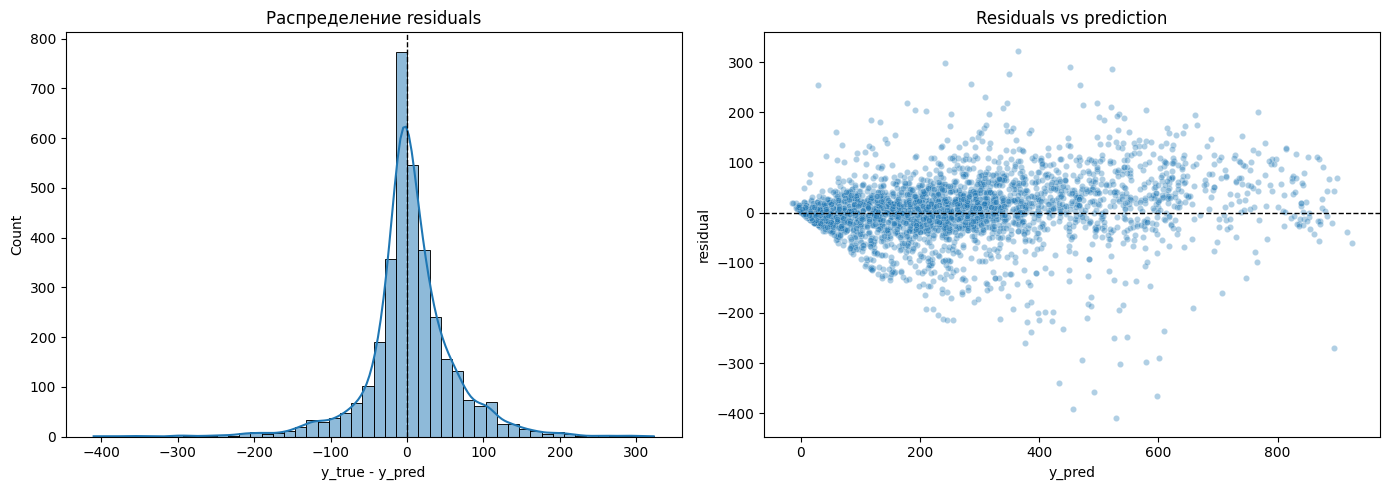

In [150]:
error_analysis_df = test_extra_df.copy()
error_analysis_df["y_true"] = error_analysis_df["cnt"]
error_analysis_df["y_pred"] = cat_final_test_pred
error_analysis_df["residual"] = error_analysis_df["y_true"] - error_analysis_df["y_pred"]
error_analysis_df["abs_error"] = error_analysis_df["residual"].abs()
error_analysis_df["squared_error"] = error_analysis_df["residual"] ** 2

error_summary = pd.DataFrame([
    {
        "split": "test",
        **regression_metrics(error_analysis_df["y_true"], error_analysis_df["y_pred"]),
        "mean_residual": error_analysis_df["residual"].mean(),
        "median_abs_error": error_analysis_df["abs_error"].median(),
        "p90_abs_error": error_analysis_df["abs_error"].quantile(0.90),
        "p95_abs_error": error_analysis_df["abs_error"].quantile(0.95),
    }
])

display(error_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(error_analysis_df["residual"], bins=50, kde=True, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Распределение residuals")
axes[0].set_xlabel("y_true - y_pred")

sns.scatterplot(
    data=error_analysis_df,
    x="y_pred",
    y="residual",
    alpha=0.35,
    s=20,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs prediction")
axes[1].set_xlabel("y_pred")
axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()


In [151]:
def error_by_group(data, group_col):
    grouped = (
        data
        .groupby(group_col)
        .agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            mean_residual=("residual", "mean"),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
    )

    rmse_by_group = (
        data
        .groupby(group_col)["squared_error"]
        .mean()
        .pow(0.5)
        .rename("RMSE")
        .reset_index()
    )

    return (
        grouped
        .merge(rmse_by_group, on=group_col)
        .sort_values("MAE", ascending=False)
        .reset_index(drop=True)
    )

error_group_tables = {}

for group_col in ["hr", "weekday", "mnth", "season", "weathersit", "workingday"]:
    table = error_by_group(error_analysis_df, group_col)
    error_group_tables[group_col] = table
    print(f"Ошибки по признаку {group_col}")
    display(table.round(4))


Ошибки по признаку hr


,hr,n,MAE,mean_residual,median_abs_error,RMSE
0,8,144,76.3408,17.6203,47.9811,109.7281
1,17,146,72.1988,18.1922,55.8091,92.5872
2,18,146,71.0468,-0.6969,55.3258,97.1652
3,19,146,55.8478,9.8636,44.2706,72.2807
4,16,146,53.1317,22.8672,38.7849,70.2831
5,15,146,52.4496,15.2897,34.0402,76.1875
6,7,144,51.0404,2.7887,28.4494,73.6614
7,12,144,50.5553,18.9074,33.9081,69.0999
8,13,146,48.4603,15.7687,29.2665,68.0340
9,14,146,46.3897,10.6468,30.6216,66.1033


Ошибки по признаку weekday


,weekday,n,MAE,mean_residual,median_abs_error,RMSE
0,6,504,43.7531,5.7096,28.1337,63.0245
1,1,480,43.6101,9.2342,23.5518,67.0588
2,2,477,39.2477,-1.9247,19.9926,63.4831
3,0,504,39.0763,2.1781,23.8713,57.4142
4,3,504,36.0435,12.1558,19.8715,57.0757
5,5,504,34.1909,3.4227,18.9554,56.8049
6,4,502,32.2386,2.6636,18.3649,49.2150


Ошибки по признаку mnth


...

,season,n,MAE,mean_residual,median_abs_error,RMSE
0,1,262,47.7058,-37.5443,27.7688,71.5553
1,4,2098,39.9353,9.6151,23.8382,60.6761
2,3,1115,32.9136,5.6883,18.8285,53.2594


Ошибки по признаку weathersit


,weathersit,n,MAE,mean_residual,median_abs_error,RMSE
0,3,238,66.0433,-1.5873,43.2762,94.4599
1,2,1075,40.7904,3.0586,23.2524,62.6482
2,1,2162,33.9565,6.3683,19.9076,52.1750


Ошибки по признаку workingday


,workingday,n,MAE,mean_residual,median_abs_error,RMSE
0,0,1127,43.9033,2.4425,27.4746,63.6265
1,1,2348,35.5634,5.9309,19.6144,57.1385


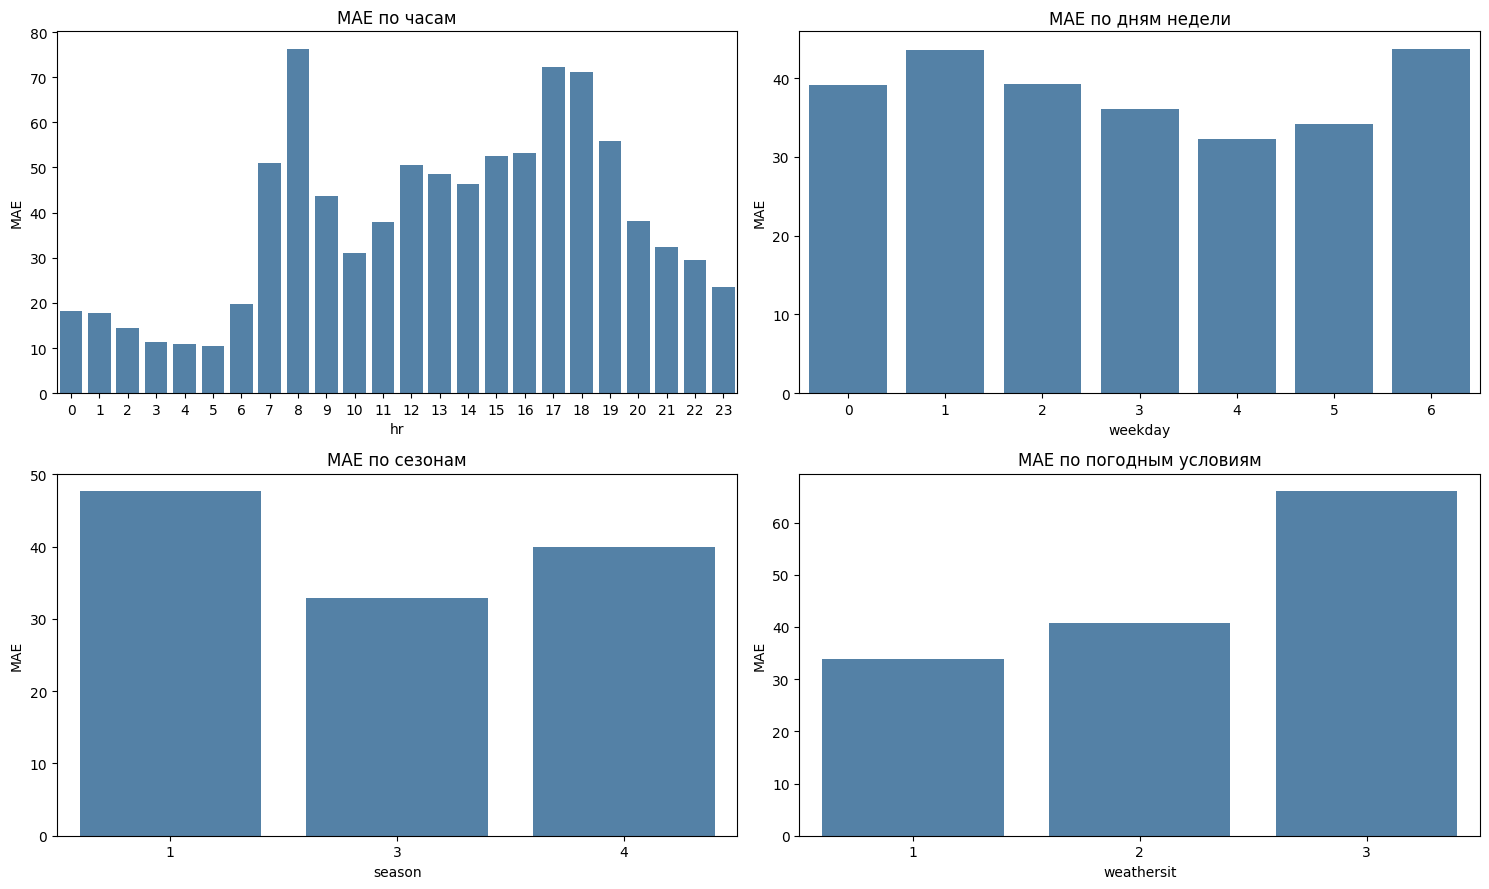

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

plot_specs = [
    ("hr", axes[0, 0], "MAE по часам"),
    ("weekday", axes[0, 1], "MAE по дням недели"),
    ("season", axes[1, 0], "MAE по сезонам"),
    ("weathersit", axes[1, 1], "MAE по погодным условиям"),
]

for group_col, ax, title in plot_specs:
    table = error_group_tables[group_col].sort_values(group_col)
    sns.barplot(data=table, x=group_col, y="MAE", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_ylabel("MAE")

plt.tight_layout()
plt.show()


In [153]:
top_error_cols = [
    "timestamp",
    "y_true",
    "y_pred",
    "residual",
    "abs_error",
    "hr",
    "weekday",
    "mnth",
    "season",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt_lag_24h",
    "cnt_lag_168h",
]

top_errors_df = (
    error_analysis_df[top_error_cols]
    .sort_values("abs_error", ascending=False)
    .head(20)
)

display(top_errors_df.round(4))

worst_hour = error_group_tables["hr"].iloc[0]
worst_weekday = error_group_tables["weekday"].iloc[0]
worst_weather = error_group_tables["weathersit"].iloc[0]

print(
    "Самые проблемные срезы по MAE: "
    f"hr={worst_hour['hr']}, "
    f"weekday={worst_weekday['weekday']}, "
    f"weathersit={worst_weather['weathersit']}."
)


/var/folders/_g/g5212r8n3g7grx3kfgpbhx980000gn/T/ipykernel_13049/3572986303.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_errors_df.round(4))


,timestamp,y_true,y_pred,residual,abs_error,hr,weekday,mnth,season,workingday,weathersit,temp,atemp,hum,windspeed,cnt_lag_24h,cnt_lag_168h
13971,2012-08-10 08:00:00,119,528.8705,-409.8705,409.8705,8,5,8,3,1,3,0.62,0.5455,0.91,0.1642,698.0,668.0
17196,2012-12-24 08:00:00,66,456.5897,-390.5897,390.5897,8,1,12,1,1,1,0.22,0.2727,0.69,0.0000,19.0,319.0
15661,2012-10-19 18:00:00,233,597.7956,-364.7956,364.7956,18,5,10,4,1,1,0.56,0.5303,0.83,0.1045,788.0,642.0
15243,2012-10-02 08:00:00,134,491.5432,-357.5432,357.5432,8,2,10,4,1,3,0.60,0.5455,0.88,0.0000,784.0,805.0
16454,2012-11-23 08:00:00,94,433.4765,-339.4765,339.4765,8,5,11,4,1,1,0.24,0.2576,0.87,0.0896,97.0,711.0
15253,2012-10-02 18:00:00,687,364.1808,322.8192,322.8192,18,2,10,4,1,3,0.62,0.5455,0.94,0.0896,613.0,822.0
14338,2012-08-25 15:00:00,233,535.1598,-302.1598,302.1598,15,6,8,3,0,2,0.64,0.6061,0.73,0.3284,350.0,596.0
16190,2012-11-12 08:00:00,540,241.7684,298.2316,298.2316,8,1,11,4,0,1,0.42,0.4242,0.82,0.1642,119.0,461.0
14917,2012-09-18 18:00:00,281,578.9317,-297.9317,297.9317,18,2,9,3,1,2,0.60,0.5455,0.88,0.1642,774.0,877.0
14066,2012-08-14 07:00:00,179,472.3721,-293.3721,293.3721,7,2,8,3,1,2,0.66,0.6061,0.83,0.0896,436.0,502.0


Самые проблемные срезы по MAE: hr=8.0, weekday=6.0, weathersit=3.0.


# Этап 10. Интерпретация финальной модели через SHAP

Интерпретируем только финальную leakage-free модель `cat_final_model`, обученную на выбранном наборе признаков. LIME не используем: для этого проекта достаточно SHAP, потому что он стандартнее для tree-based моделей и лучше подходит для глобальной и локальной интерпретации CatBoost.

Важно: SHAP объясняет поведение модели, а не доказывает причинные связи.

In [154]:
import shap
from catboost import Pool

shap_sample_size = min(1000, len(test_extra_df))
X_shap = test_extra_df[final_features].sample(
    n=shap_sample_size,
    random_state=42,
)

shap_pool = Pool(
    X_shap,
    cat_features=final_cat_features,
)

shap_raw = cat_final_model.get_feature_importance(
    shap_pool,
    type="ShapValues",
)

shap_values_array = shap_raw[:, :-1]
shap_base_values = shap_raw[:, -1]

shap_values = shap.Explanation(
    values=shap_values_array,
    base_values=shap_base_values,
    data=X_shap,
    feature_names=final_features,
)

shap_importance_df = (
    pd.DataFrame({
        "feature": final_features,
        "mean_abs_shap": np.abs(shap_values_array).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(25).round(4))


,feature,mean_abs_shap
0,yr,37.6170
1,cnt_lag_24h,33.0276
2,cnt_lag_168h,30.6465
3,is_working_day_rush,28.2545
4,temp,17.8940
5,hr_sin,15.7878
6,hr,15.2435
7,is_night,15.1910
8,hr_cos,13.7910
9,atemp,11.8850


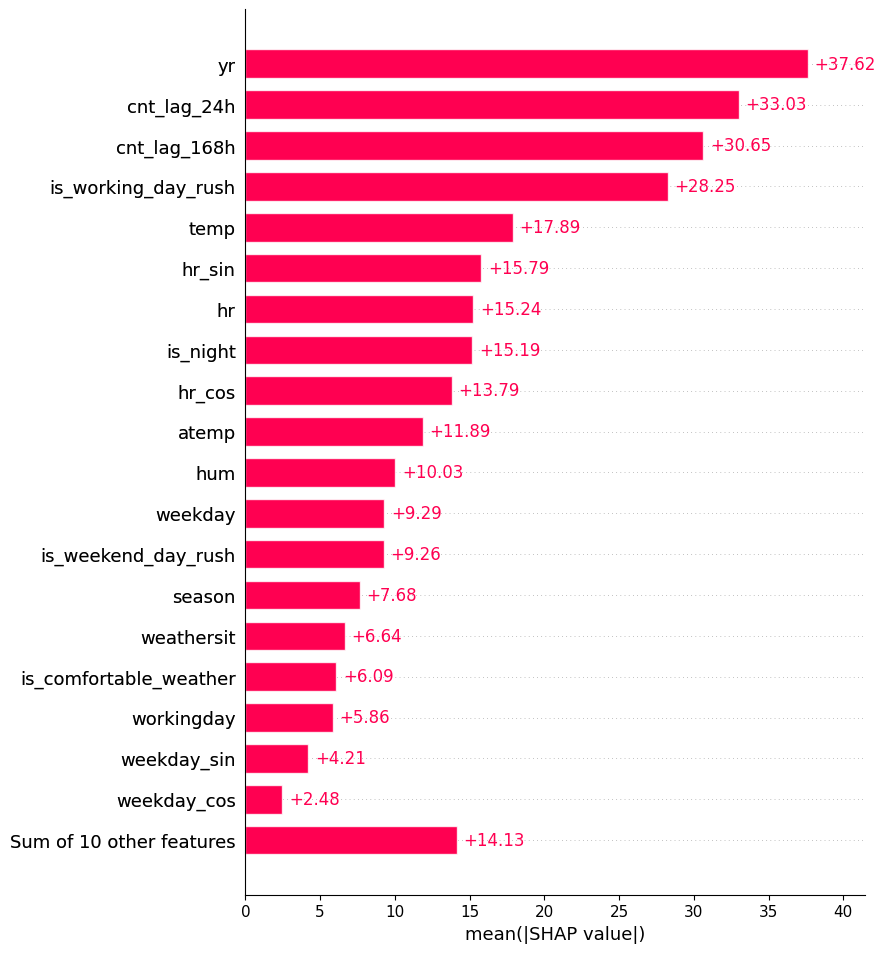

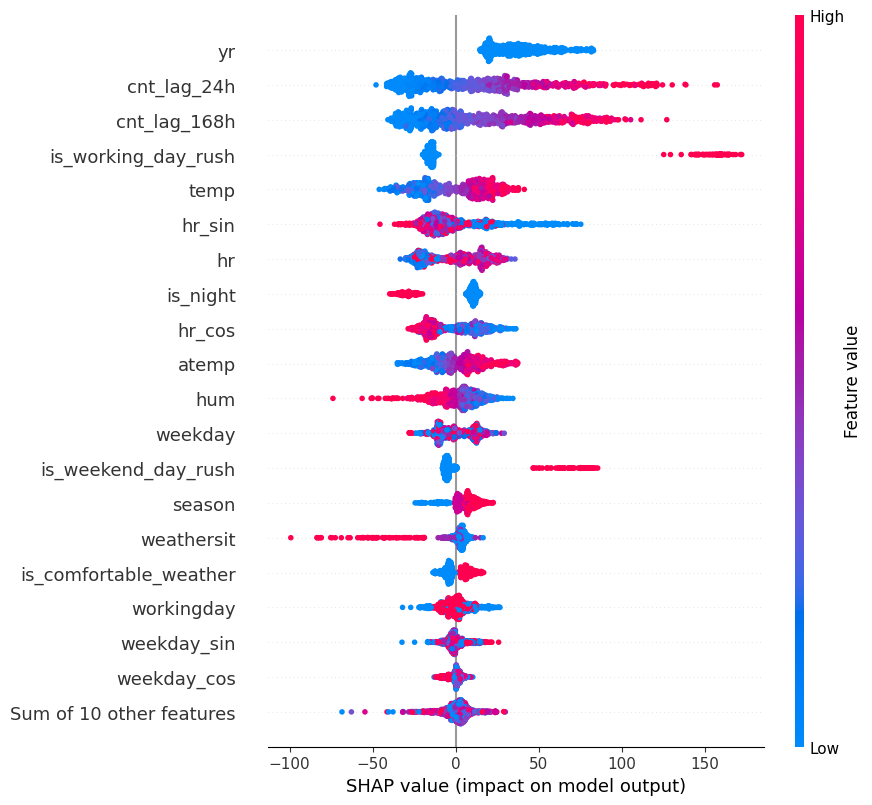

In [155]:
shap.plots.bar(shap_values, max_display=20)
shap.plots.beeswarm(shap_values, max_display=20)


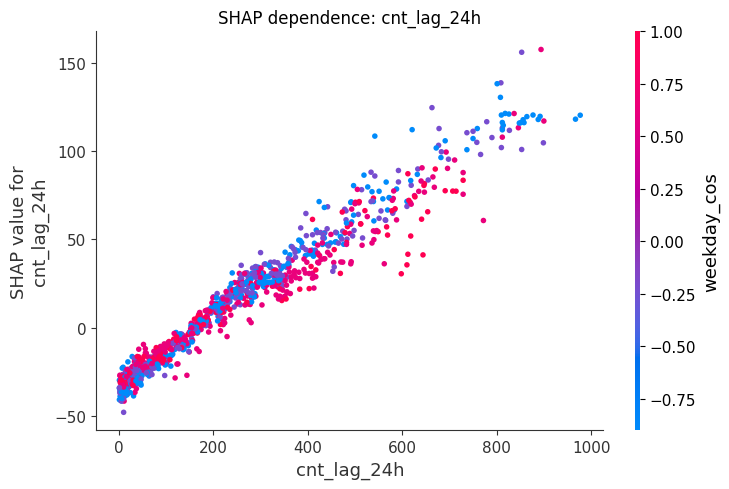

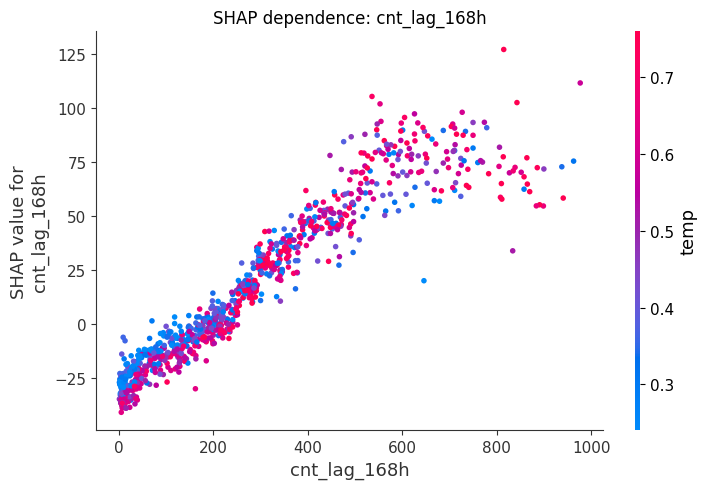

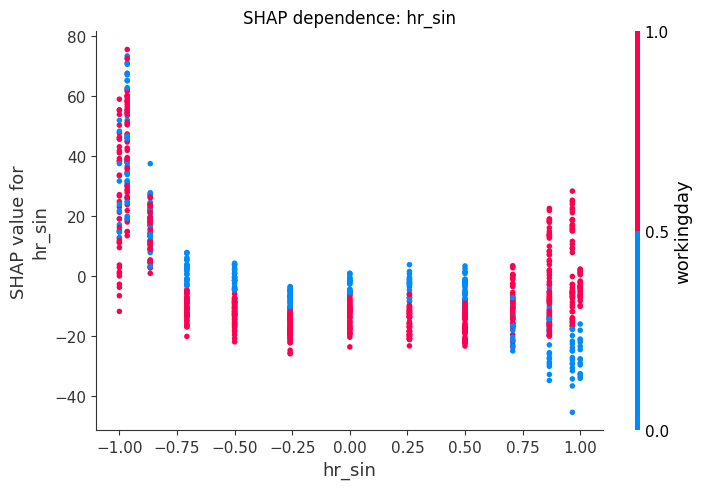

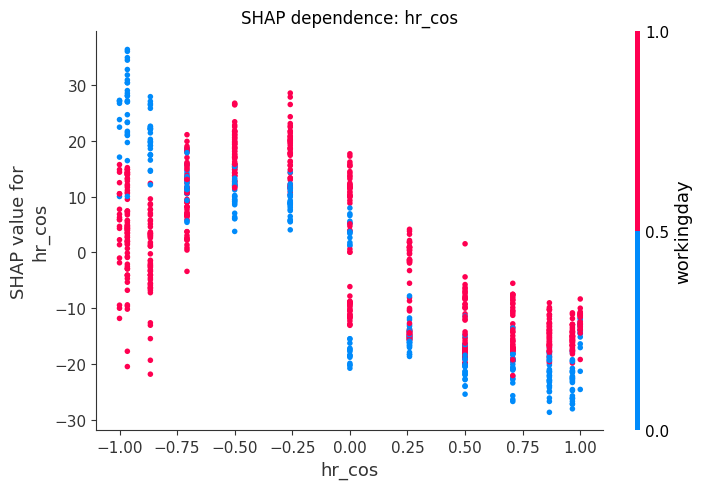

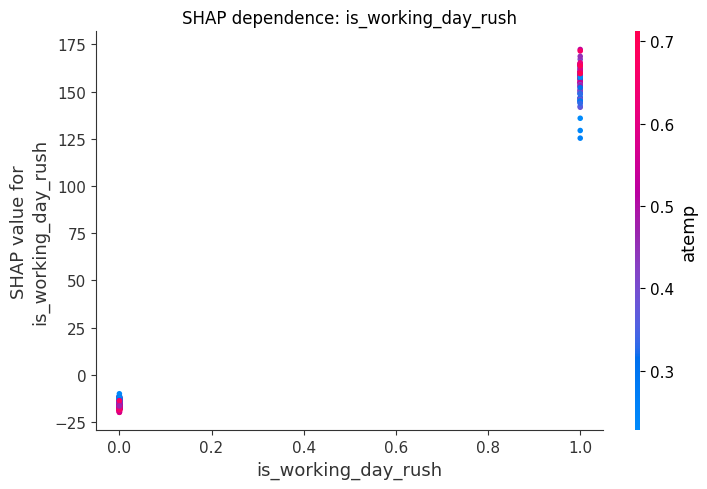

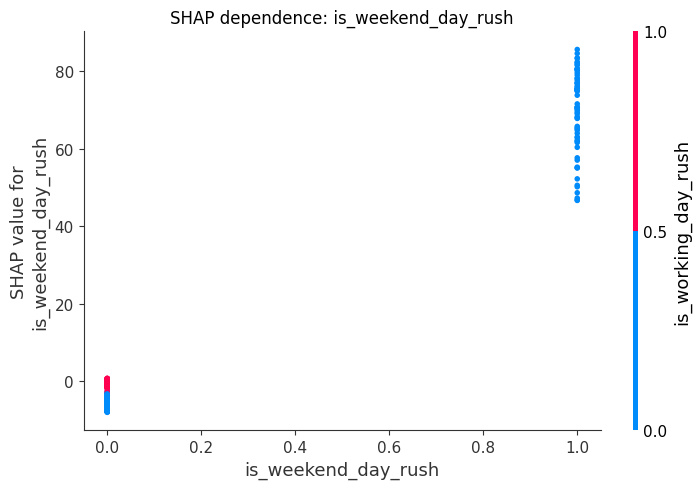

In [156]:
dependence_features = [
    "cnt_lag_24h",
    "cnt_lag_168h",
    "hr_sin",
    "hr_cos",
    "is_working_day_rush",
    "is_weekend_day_rush",
]

dependence_features = [
    feature for feature in dependence_features
    if feature in final_features
]

for feature in dependence_features:
    shap.dependence_plot(
        feature,
        shap_values_array,
        X_shap,
        feature_names=final_features,
        show=False,
    )
    plt.title(f"SHAP dependence: {feature}")
    plt.tight_layout()
    plt.show()


/var/folders/_g/g5212r8n3g7grx3kfgpbhx980000gn/T/ipykernel_13049/2044257343.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(local_examples_info.round(4))


,timestamp,y_true,y_pred,residual,abs_error,hr,weekday,mnth,season,workingday,weathersit,temp,atemp,hum,windspeed,cnt_lag_24h,cnt_lag_168h
13971,2012-08-10 08:00:00,119,528.8705,-409.8705,409.8705,8,5,8,3,1,3,0.62,0.5455,0.91,0.1642,698.0,668.0
17196,2012-12-24 08:00:00,66,456.5897,-390.5897,390.5897,8,1,12,1,1,1,0.22,0.2727,0.69,0.0000,19.0,319.0
15661,2012-10-19 18:00:00,233,597.7956,-364.7956,364.7956,18,5,10,4,1,1,0.56,0.5303,0.83,0.1045,788.0,642.0


Local SHAP для наблюдения index=13971


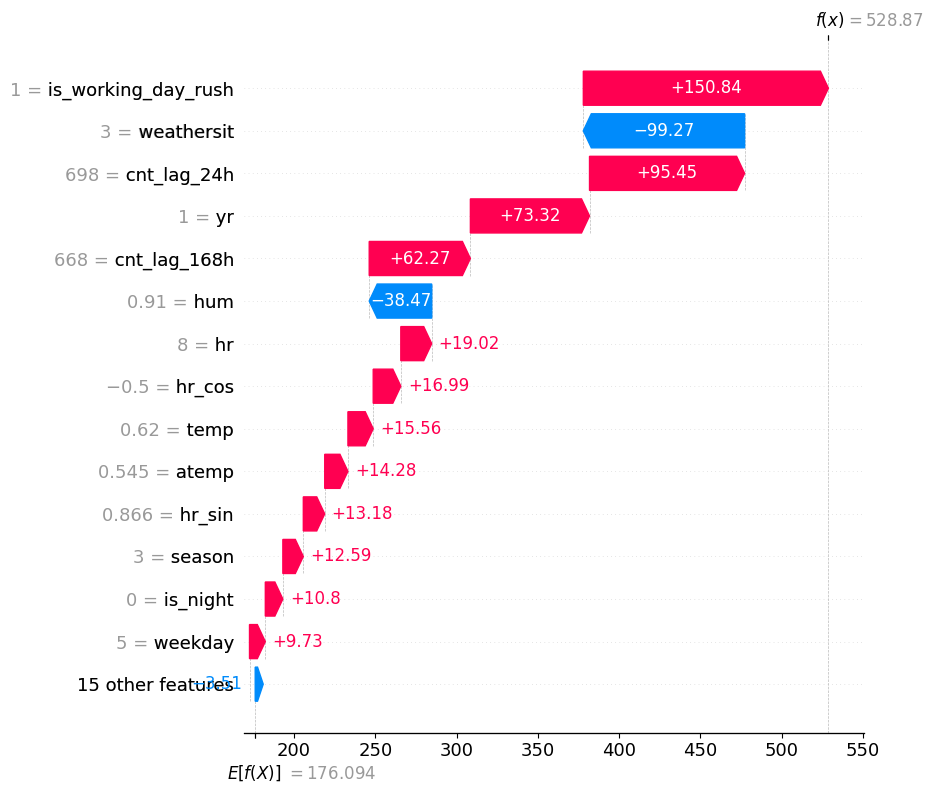

Local SHAP для наблюдения index=17196


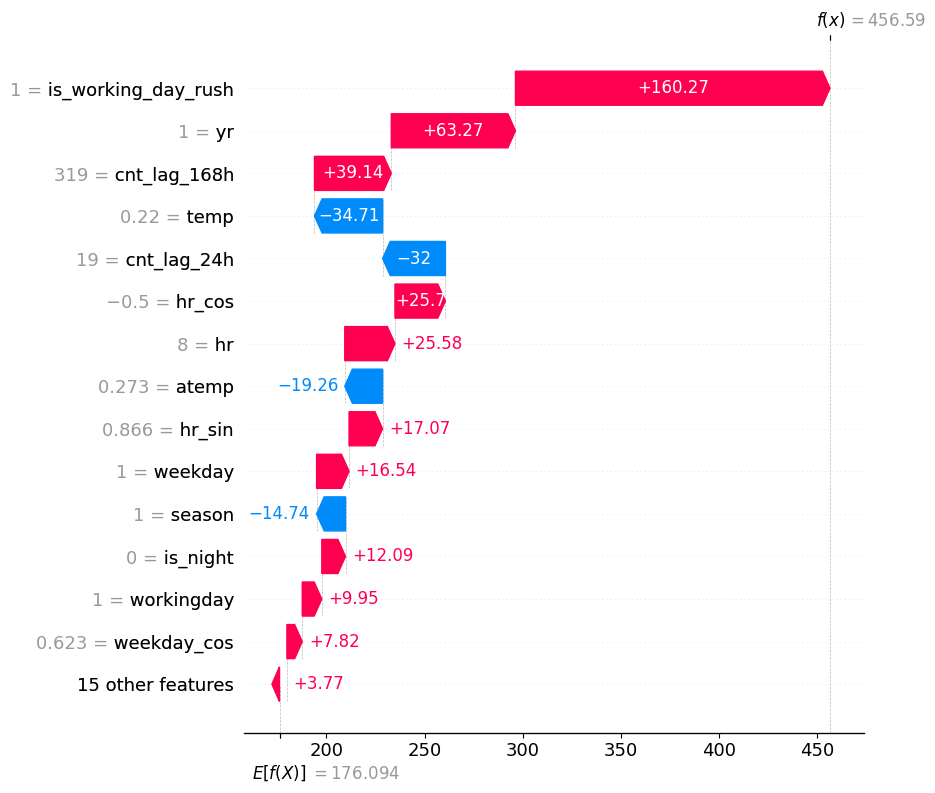

Local SHAP для наблюдения index=15661


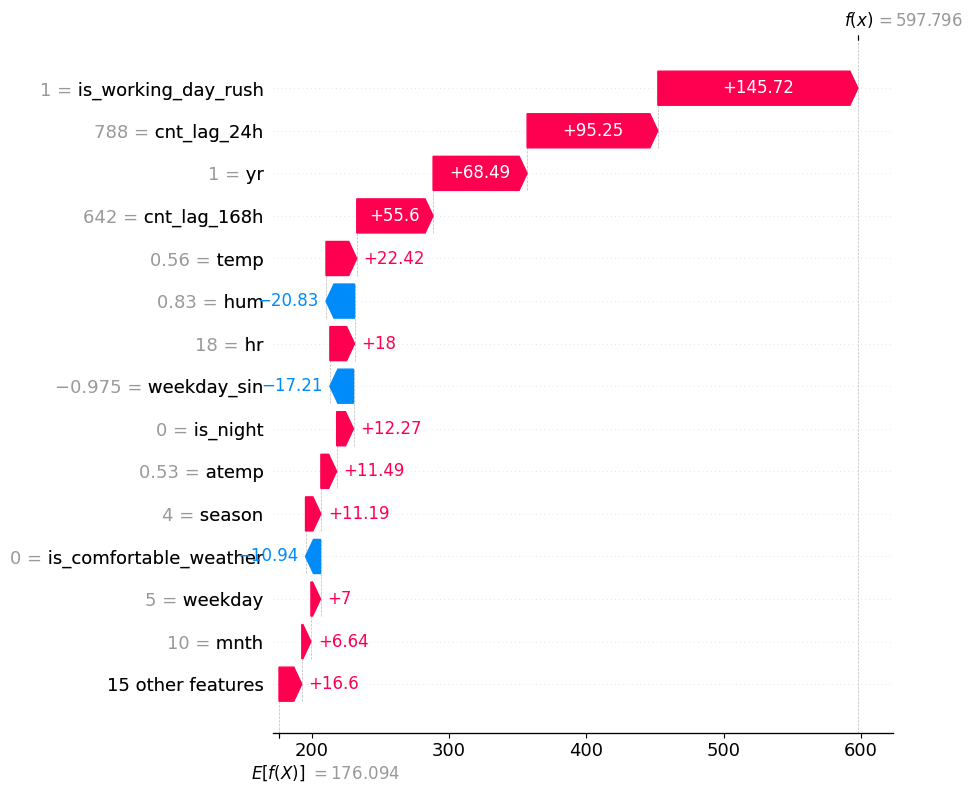

In [157]:
local_example_indices = (
    error_analysis_df
    .sort_values("abs_error", ascending=False)
    .head(3)
    .index
)

local_X = test_extra_df.loc[local_example_indices, final_features]
local_pool = Pool(local_X, cat_features=final_cat_features)

local_shap_raw = cat_final_model.get_feature_importance(
    local_pool,
    type="ShapValues",
)

local_shap_values = shap.Explanation(
    values=local_shap_raw[:, :-1],
    base_values=local_shap_raw[:, -1],
    data=local_X.to_numpy(),
    feature_names=final_features,
)

local_examples_info = error_analysis_df.loc[local_example_indices, top_error_cols]
display(local_examples_info.round(4))

for i, row_index in enumerate(local_example_indices):
    print(f"Local SHAP для наблюдения index={row_index}")
    shap.plots.waterfall(local_shap_values[i], max_display=15)


## Вывод по интерпретации

После выполнения SHAP-блока финальные выводы нужно формулировать по `shap_importance_df`, beeswarm plot и локальным waterfall-графикам.

Ожидаемая логика вывода:

1. Основной сигнал модели должен идти от истории спроса (`cnt_lag_24h`, `cnt_lag_168h`) и времени (`hr`, `hr_sin`, `hr_cos`, rush-hour признаки).
2. Погодные признаки обычно слабее календарных и исторических, но помогают корректировать прогноз в неблагоприятных условиях.
3. Локальные waterfall-графики показывают, почему модель ошиблась на конкретных часах с максимальной ошибкой.
4. Эти выводы относятся к модели и данным Washington D.C.; для другого города нужна локальная история спроса и переобучение.